#Spread-Filtered Features: Filtering the Right Thing

## Motivation

The previous two experiments (v1 and v2 horizon grid search) applied a causal FFT
low-pass filter to individual price series A and B before computing features.
Both failed because filtering prices separately destroys the cross-asset relationship:
`log(filtered_B / filtered_A) ≠ filtered(log B/A)`, and the filter-induced divergence
between the two series introduces spurious signals unrelated to pair dynamics.

## Key insight

For a cointegrated pair, the quantity with meaningful frequency structure is the
**spread** `s_t = log(B_t / A_t)` — not the individual prices. The spread is
(approximately) stationary and mean-reverting. Its low-frequency component captures
the slow drift of the cointegrating relationship; its high-frequency component is noise.

Filtering `s_t` directly gives us two clean, interpretable signals:

- `spread_trend`: the causal low-pass filtered spread — where is the pair in its
  long-run equilibrium cycle?
- `spread_residual = s_t - spread_trend`: how far has the spread deviated from
  its trend? This is the mean-reversion signal — a large positive residual means
  B is expensive relative to A and should revert downward.

## Three-way comparison

We test three feature sets across all pairs and horizons:

1. **raw**: lagged returns, rolling vol, cointegration z-score (no FFT)
2. **spread_filter**: raw features PLUS spread_trend and spread_residual
   (FFT applied to the spread, features added on top of raw — not replacing them)
3. **spread_filter_only**: only the FFT-derived spread features (ablation)

The key question: does `spread_filter` beat `raw`? If yes, the FFT adds value
when applied to the theoretically correct quantity.

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from typing import List, Tuple, Optional, Dict
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

In [25]:
# ============================================
# 1. Config
# ============================================

PAIRS = {
    "energy_etfs":          ("XLE", "XOP"),
    "metals_etfs":          ("GLD", "SLV"),
    "consumer_defensive":   ("XLP", "KO"),
    "tech_baskets":         ("XLK", "QQQ"),
    "rates_etfs":           ("TLT", "IEF"),
    "fertilizer_equities":  ("CF",  "NTR"),
}

START_DATE = "2018-01-01"
END_DATE   = None

HORIZONS    = [1, 5, 10, 21, 42, 63]
BASE_N_LAGS = 10

TRAIN_FRAC = 0.60
VAL_FRAC   = 0.20
TEST_FRAC  = 0.20

# FFT grid — applied to the SPREAD, not prices.
# keep_period is unconstrained here (we let the tuner find it freely,
# since we are no longer conflating filter design with horizon anchoring).
FFT_WINDOWS  = [20, 40, 60, 90, 120]
KEEP_PERIODS = [5, 10, 20, 40, 60]
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

TRANSACTION_COST = 0.001  # 10 bps one-way

# Dataset labels used throughout
DS_RAW        = "raw"
DS_SPREAD_FFT = "spread_filter"       # raw features + FFT spread features
DS_FFT_ONLY   = "spread_filter_only"  # ablation: only FFT spread features

In [26]:
# ============================================
# 2. Data download (cached)
# ============================================

try:
    from yfinance import cache as _yfc
    _yfc.set_caching(False)
except Exception:
    pass


def download_pair_prices(
    ticker_a: str, ticker_b: str,
    start: str = START_DATE, end: Optional[str] = END_DATE
) -> pd.DataFrame:
    data = yf.download(
        [ticker_a, ticker_b], start=start, end=end,
        auto_adjust=True, progress=False
    )
    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"].copy() if "Close" in data.columns.get_level_values(0) \
                 else data.xs(data.columns.levels[0][0], axis=1, level=0).copy()
    else:
        prices = data.copy()
    prices = prices[[ticker_a, ticker_b]].dropna().copy()
    prices.columns = ["A", "B"]
    return prices


_price_cache: dict = {}

def get_prices(ticker_a: str, ticker_b: str) -> pd.DataFrame:
    key = (ticker_a, ticker_b)
    if key not in _price_cache:
        _price_cache[key] = download_pair_prices(ticker_a, ticker_b)
    return _price_cache[key].copy()

In [27]:
# ============================================
# 3. Causal FFT filter — applied to the SPREAD
# ============================================

def fft_lowpass_last_value(x: np.ndarray, keep_period_days: int) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.nan
    x_mean        = np.mean(x)
    fft_vals      = np.fft.rfft(x - x_mean)
    freqs         = np.fft.rfftfreq(len(x), d=1.0)
    mask          = freqs <= 1.0 / keep_period_days
    reconstructed = np.fft.irfft(fft_vals * mask, n=len(x)) + x_mean
    return float(reconstructed[-1])


def causal_fft_lowpass_series(
    series: pd.Series, fft_window: int, keep_period_days: int
) -> pd.Series:
    """Rolling causal FFT low-pass filter on a 1D series."""
    s      = series.astype(float).copy()
    out    = pd.Series(index=s.index, dtype=float)
    values = s.values
    for i in range(len(values)):
        if i + 1 < fft_window:
            out.iloc[i] = np.nan
            continue
        window_vals = values[i - fft_window + 1 : i + 1]
        if np.isnan(window_vals).any():
            out.iloc[i] = np.nan
            continue
        out.iloc[i] = fft_lowpass_last_value(window_vals, keep_period_days)
    return out


def causal_fft_spread(
    prices: pd.DataFrame,
    fft_window: int,
    keep_period_days: int,
    warmup_prices: Optional[pd.DataFrame] = None
) -> Tuple[pd.Series, pd.Series]:
    """
    Compute the causal FFT low-pass filter on the LOG SPREAD s_t = log(B/A).

    Returns:
        spread_trend    : filtered spread (low-frequency component)
        spread_residual : s_t - spread_trend (high-frequency deviation)

    If warmup_prices is provided, prepend its tail to avoid cold-start
    at the boundary (same fix as in previous notebooks).
    """
    log_spread = np.log(prices["B"] / prices["A"])

    if warmup_prices is not None and len(warmup_prices) >= fft_window:
        warmup_spread = np.log(warmup_prices["B"] / warmup_prices["A"])
        prefix        = warmup_spread.iloc[-fft_window:]
        combined      = pd.concat([prefix, log_spread])
        trend_combined = causal_fft_lowpass_series(combined, fft_window, keep_period_days)
        spread_trend   = trend_combined.loc[log_spread.index]
    else:
        spread_trend = causal_fft_lowpass_series(log_spread, fft_window, keep_period_days)

    spread_residual = log_spread - spread_trend
    return spread_trend, spread_residual

In [28]:
# ============================================
# 4. Feature engineering
# ============================================

FEATURE_EXCLUDE = {"A", "B", "y", "y_raw"}

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if c not in FEATURE_EXCLUDE]


def make_base_features(
    prices: pd.DataFrame,
    n_lags: int,
    target_horizon: int
) -> pd.DataFrame:
    """
    Build the raw (non-FFT) feature set. All features are lagged by at
    least 1 day so no same-day information leaks into the prediction.

    Features:
      - Lagged log returns of A and B (lags 1..n_lags)
      - Lagged spread returns (lags 1..n_lags)
      - Rolling vol of A and B (10-day)
      - Rolling A-B correlation (20-day)
      - Momentum contrast: 1-day vs 5-day spread
      - Horizon-scale momentum: cumulative spread over target_horizon days
      - Cointegration z-score: rolling 60-day normalised log(B/A)
    """
    df = pd.DataFrame(index=prices.index)

    ret_A_raw  = np.log(prices["A"]).diff()
    ret_B_raw  = np.log(prices["B"]).diff()
    spread_raw = ret_B_raw - ret_A_raw

    ret_A_lag1  = ret_A_raw.shift(1)
    ret_B_lag1  = ret_B_raw.shift(1)
    spread_lag1 = spread_raw.shift(1)

    df["ret_A"]      = ret_A_lag1
    df["ret_B"]      = ret_B_lag1
    df["spread_ret"] = spread_lag1

    for lag in range(2, n_lags + 1):
        df[f"ret_A_lag_{lag}"]  = ret_A_raw.shift(lag)
        df[f"ret_B_lag_{lag}"]  = ret_B_raw.shift(lag)
        df[f"spread_lag_{lag}"] = spread_raw.shift(lag)

    df["vol_A_10"]   = ret_A_lag1.rolling(10).std()
    df["vol_B_10"]   = ret_B_lag1.rolling(10).std()
    df["corr_20"]    = ret_A_lag1.rolling(20).corr(ret_B_lag1)

    df["mom_spread_1d"] = spread_lag1
    df["mom_spread_5d"] = spread_raw.rolling(5).sum().shift(1)
    df["mom_contrast"]  = df["mom_spread_1d"] - df["mom_spread_5d"] / 5.0
    df["mom_horizon"]   = spread_raw.rolling(target_horizon).sum().shift(1)

    # Rolling z-score of log(B/A) — the standard cointegration signal
    log_ratio = np.log(prices["B"] / prices["A"])
    roll_mean = log_ratio.rolling(60).mean()
    roll_std  = log_ratio.rolling(60).std()
    df["zscore_spread"] = ((log_ratio - roll_mean) / (roll_std + 1e-8)).shift(1)

    df["A"] = prices["A"]
    df["B"] = prices["B"]

    return df


def add_spread_fft_features(
    df: pd.DataFrame,
    prices: pd.DataFrame,
    fft_window: int,
    keep_period_days: int,
    warmup_prices: Optional[pd.DataFrame] = None
) -> pd.DataFrame:
    """
    Add FFT-derived spread features to an existing feature DataFrame.

    New features (all lagged by 1 to avoid leakage):
      spread_trend      : low-frequency component of log(B/A)
      spread_residual   : raw spread minus trend (mean-reversion deviation)
      spread_trend_chg  : 1-day change in trend (trend momentum)
      residual_zscore   : rolling z-score of residual (normalised deviation)
      residual_sign_chg : did residual cross zero recently? (reversion trigger)

    These are the theoretically correct FFT features for a mean-reverting
    spread: the residual tells you HOW FAR the pair has moved from its
    low-frequency equilibrium, which is the primary pair-trading signal.
    """
    df = df.copy()

    spread_trend, spread_residual = causal_fft_spread(
        prices, fft_window, keep_period_days, warmup_prices
    )

    # Lag everything by 1 — these are known at end of day t-1
    df["spread_trend"]     = spread_trend.shift(1)
    df["spread_residual"]  = spread_residual.shift(1)
    df["spread_trend_chg"] = spread_trend.diff().shift(1)

    # Normalised residual: how many rolling-std units away from zero?
    # spread_residual is at time t (known at close of day t).
    # resid_std rolling window ends at t — also known at close of day t.
    # The final .shift(1) moves the whole quantity to t-1, so the feature
    # at row t reflects data known at end of the previous day. Clean.
    resid_std = spread_residual.rolling(20).std()
    df["residual_zscore"] = (spread_residual / (resid_std + 1e-8)).shift(1)

    # Sign-change indicator: did residual cross zero in the 3 days before t?
    # rolling(3) at position t covers {t-2, t-1, t}; after .shift(1) the
    # feature at row t covers {t-3, t-2, t-1} — fully lagged.
    resid_sign = np.sign(spread_residual)
    df["residual_sign_chg"] = (
        resid_sign.rolling(3).apply(
            lambda x: 1.0 if len(set(x)) > 1 else 0.0, raw=True
        ).shift(1)
    )

    return df


def add_target(
    df: pd.DataFrame,
    prices: pd.DataFrame,
    target_horizon: int
) -> pd.DataFrame:
    """Attach vol-normalised target y and raw y to a feature DataFrame."""
    df = df.copy()

    future_ret_A = np.log(prices["A"].shift(-target_horizon) / prices["A"])
    future_ret_B = np.log(prices["B"].shift(-target_horizon) / prices["B"])
    raw_y        = future_ret_B - future_ret_A

    # Vol normalise using spread return vol.
    # shift(1) lags by one day so the vol denominator only uses
    # returns known at close of day t-1 (no same-day leakage).
    # Only one shift is needed — the previous code applied two.
    spread_raw   = np.log(prices["B"]).diff() - np.log(prices["A"]).diff()
    vol_window   = min(max(20, target_horizon), 60)
    spread_vol   = spread_raw.shift(1).rolling(vol_window).std()

    df["y_raw"] = raw_y
    df["y"]     = raw_y / (spread_vol + 1e-8)

    return df.dropna().copy()


def make_raw_dataset(
    prices: pd.DataFrame, n_lags: int, target_horizon: int
) -> pd.DataFrame:
    df = make_base_features(prices, n_lags, target_horizon)
    return add_target(df, prices, target_horizon)


def make_spread_fft_dataset(
    prices: pd.DataFrame,
    n_lags: int,
    target_horizon: int,
    fft_window: int,
    keep_period_days: int,
    warmup_prices: Optional[pd.DataFrame] = None,
    fft_only: bool = False
) -> pd.DataFrame:
    """
    Build the spread-FFT feature set.

    fft_only=False  -> raw features + FFT spread features  (DS_SPREAD_FFT)
    fft_only=True   -> only FFT spread features             (DS_FFT_ONLY)
    """
    if fft_only:
        # Start with a minimal skeleton (prices + index) then add FFT features
        df = pd.DataFrame(index=prices.index)
        df["A"] = prices["A"]
        df["B"] = prices["B"]
    else:
        df = make_base_features(prices, n_lags, target_horizon)

    df = add_spread_fft_features(df, prices, fft_window, keep_period_days, warmup_prices)
    return add_target(df, prices, target_horizon)

In [29]:
# ============================================
# 5. Evaluation helpers
# ============================================

def score(
    y_test: np.ndarray,
    preds: np.ndarray,
    y_raw_test: np.ndarray,
    transaction_cost: float = TRANSACTION_COST
) -> dict:
    rmse     = float(mean_squared_error(y_test, preds) ** 0.5)
    r2       = float(r2_score(y_test, preds))
    sign_acc = float(np.mean(np.sign(preds) == np.sign(y_test)))

    n_correct  = int(np.sum(np.sign(preds) == np.sign(y_test)))
    binom_pval = float(
        stats.binomtest(n_correct, len(y_test), p=0.5, alternative="greater").pvalue
    )

    positions = np.sign(preds)
    turns     = np.abs(np.diff(np.concatenate([[0], positions])))
    net_pnl   = float(np.mean(positions * y_raw_test - turns * transaction_cost))

    return dict(rmse=rmse, r2=r2, sign_acc=sign_acc,
                sign_acc_pval=binom_pval, net_pnl_per_day=net_pnl)


def fit_and_score(
    model,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    stride: int = 1
) -> dict:
    features = get_feature_columns(train_df)
    model.fit(train_df[features].values, train_df["y"].values)
    test_sub = test_df.iloc[::stride]
    preds    = model.predict(test_sub[features].values)
    return score(test_sub["y"].values, preds, test_sub["y_raw"].values)

In [30]:
# ============================================
# 6. Tune FFT params on the spread filter
# ============================================

def tune_spread_fft_params(
    prices_train: pd.DataFrame,
    prices_val: pd.DataFrame,
    fft_windows: List[int],
    keep_periods: List[int],
    ridge_alphas: List[float],
    n_lags: int,
    target_horizon: int
) -> Tuple[int, int, float]:
    """
    Joint grid-search over (fft_window, keep_period, ridge_alpha).

    Tuning is done on the spread_filter dataset (raw + FFT features)
    evaluated with stride subsampling to avoid overlap bias.
    keep_period is unconstrained relative to horizon — the tuner finds
    the best frequency decomposition of the spread freely.
    """
    best_rmse   = np.inf
    best_params = (fft_windows[0], keep_periods[0], ridge_alphas[2])
    stride      = max(1, target_horizon)

    for fw in fft_windows:
        for kp in keep_periods:
            if kp > fw:
                continue
            tr = make_spread_fft_dataset(
                prices_train, n_lags, target_horizon,
                fw, kp, warmup_prices=None, fft_only=False
            )
            va = make_spread_fft_dataset(
                prices_val, n_lags, target_horizon,
                fw, kp, warmup_prices=prices_train, fft_only=False
            )
            if len(tr) == 0 or len(va) == 0:
                continue
            for alpha in ridge_alphas:
                m   = Ridge(alpha=alpha)
                res = fit_and_score(m, tr, va, stride=stride)
                if res["rmse"] < best_rmse:
                    best_rmse   = res["rmse"]
                    best_params = (fw, kp, alpha)

    return best_params

In [31]:
# ============================================
# 7. Single (pair, horizon) experiment
# ============================================

def run_one(
    pair_name: str, ticker_a: str, ticker_b: str, target_horizon: int
) -> List[dict]:
    prices = get_prices(ticker_a, ticker_b)
    n_lags = max(BASE_N_LAGS, target_horizon)
    stride = max(1, target_horizon)

    n  = len(prices)
    i1 = int(n * TRAIN_FRAC)
    i2 = int(n * (TRAIN_FRAC + VAL_FRAC))

    p_train    = prices.iloc[:i1].copy()
    p_val      = prices.iloc[i1:i2].copy()
    p_test     = prices.iloc[i2:].copy()
    p_trainval = prices.iloc[:i2].copy()

    # ---- Tune FFT params on train+val ----
    n_tv    = len(p_trainval)
    i_split = int(n_tv * 0.75)
    best_fw, best_kp, best_alpha = tune_spread_fft_params(
        p_trainval.iloc[:i_split],
        p_trainval.iloc[i_split:],
        FFT_WINDOWS, KEEP_PERIODS, RIDGE_ALPHAS,
        n_lags, target_horizon
    )

    # ---- Build all three datasets ----
    raw_train = make_raw_dataset(p_train, n_lags, target_horizon)
    raw_test  = make_raw_dataset(p_test,  n_lags, target_horizon)

    fft_train = make_spread_fft_dataset(
        p_train, n_lags, target_horizon, best_fw, best_kp,
        warmup_prices=None, fft_only=False
    )
    fft_test = make_spread_fft_dataset(
        p_test, n_lags, target_horizon, best_fw, best_kp,
        warmup_prices=p_trainval, fft_only=False
    )

    fft_only_train = make_spread_fft_dataset(
        p_train, n_lags, target_horizon, best_fw, best_kp,
        warmup_prices=None, fft_only=True
    )
    fft_only_test = make_spread_fft_dataset(
        p_test, n_lags, target_horizon, best_fw, best_kp,
        warmup_prices=p_trainval, fft_only=True
    )

    models = {
        "Ridge":              Ridge(alpha=best_alpha),
        "RandomForest":       RandomForestRegressor(
            n_estimators=300, max_depth=5,
            min_samples_leaf=10, random_state=42
        ),
        "LinearRegression":   LinearRegression(),
    }

    datasets = [
        (DS_RAW,        raw_train,      raw_test),
        (DS_SPREAD_FFT, fft_train,      fft_test),
        (DS_FFT_ONLY,   fft_only_train, fft_only_test),
    ]

    rows = []
    for model_name, model in models.items():
        for ds_name, tr, te in datasets:
            if len(tr) == 0 or len(te) == 0:
                continue
            m   = clone(model)
            res = fit_and_score(m, tr, te, stride=stride)
            rows.append(dict(
                pair=pair_name,
                tickers=f"{ticker_a}/{ticker_b}",
                horizon=target_horizon,
                model=model_name,
                dataset=ds_name,
                best_fft_window=best_fw,
                best_keep_period=best_kp,
                best_ridge_alpha=best_alpha,
                **res
            ))
    return rows

In [32]:
# ============================================
# 8. Full grid search: all pairs x all horizons
# ============================================

all_rows = []

for horizon in HORIZONS:
    print(f"\n=== Horizon = {horizon} days ===")
    for pair_name, (ticker_a, ticker_b) in PAIRS.items():
        print(f"  {pair_name} ({ticker_a}/{ticker_b}) ...", end=" ", flush=True)
        try:
            rows = run_one(pair_name, ticker_a, ticker_b, horizon)
            all_rows.extend(rows)
            print("done")
        except Exception as e:
            print(f"FAILED: {e}")

results = pd.DataFrame(all_rows)
print(f"\nTotal result rows: {len(results)}")


=== Horizon = 1 days ===
  energy_etfs (XLE/XOP) ... done
  metals_etfs (GLD/SLV) ... done
  consumer_defensive (XLP/KO) ... done
  tech_baskets (XLK/QQQ) ... done
  rates_etfs (TLT/IEF) ... done
  fertilizer_equities (CF/NTR) ... done

=== Horizon = 5 days ===
  energy_etfs (XLE/XOP) ... done
  metals_etfs (GLD/SLV) ... done
  consumer_defensive (XLP/KO) ... done
  tech_baskets (XLK/QQQ) ... done
  rates_etfs (TLT/IEF) ... done
  fertilizer_equities (CF/NTR) ... done

=== Horizon = 10 days ===
  energy_etfs (XLE/XOP) ... done
  metals_etfs (GLD/SLV) ... done
  consumer_defensive (XLP/KO) ... done
  tech_baskets (XLK/QQQ) ... done
  rates_etfs (TLT/IEF) ... done
  fertilizer_equities (CF/NTR) ... done

=== Horizon = 21 days ===
  energy_etfs (XLE/XOP) ... done
  metals_etfs (GLD/SLV) ... done
  consumer_defensive (XLP/KO) ... done
  tech_baskets (XLK/QQQ) ... done
  rates_etfs (TLT/IEF) ... done
  fertilizer_equities (CF/NTR) ... done

=== Horizon = 42 days ===
  energy_etfs (XLE/XOP)

In [33]:
# ============================================
# 9. Improvement tables
# ============================================

# Pivot to get raw, spread_filter, spread_filter_only side by side
pivot = results.pivot_table(
    index=["pair", "model", "horizon"],
    columns="dataset",
    values=["rmse", "r2", "sign_acc", "net_pnl_per_day"]
).reset_index()
pivot.columns = ["_".join(c).strip("_") for c in pivot.columns]

raw_col   = f"rmse_{DS_RAW}"
fft_col   = f"rmse_{DS_SPREAD_FFT}"
fonly_col = f"rmse_{DS_FFT_ONLY}"

pivot["rmse_improvement_fft"]      = pivot[raw_col]   - pivot[fft_col]
pivot["rmse_improvement_fft_only"] = pivot[raw_col]   - pivot[fonly_col]
pivot["r2_improvement_fft"]        = pivot[f"r2_{DS_SPREAD_FFT}"]  - pivot[f"r2_{DS_RAW}"]
pivot["pnl_improvement_fft"]       = pivot[f"net_pnl_per_day_{DS_SPREAD_FFT}"] - pivot[f"net_pnl_per_day_{DS_RAW}"]

imp_mean = (
    pivot.groupby(["model", "horizon"])[
        ["rmse_improvement_fft", "rmse_improvement_fft_only", "pnl_improvement_fft"]
    ].mean().reset_index()
)

print("=== Mean RMSE improvement: spread_filter vs raw ===")
print("Positive = spread FFT features help")
print()
print(
    imp_mean.pivot(index="horizon", columns="model", values="rmse_improvement_fft")
    .to_string()
)

print()
print("=== Mean RMSE improvement: spread_filter_only vs raw (ablation) ===")
print(
    imp_mean.pivot(index="horizon", columns="model", values="rmse_improvement_fft_only")
    .to_string()
)

print()
print("=== Crossover horizons (spread_filter vs raw) ===")
for model in pivot["model"].unique():
    for pair in pivot["pair"].unique():
        sub = pivot[(pivot["model"] == model) & (pivot["pair"] == pair)].sort_values("horizon")
        pos = sub[sub["rmse_improvement_fft"] > 0]
        if len(pos) > 0:
            first = pos.iloc[0]
            print(f"  {pair:25s} | {model:20s} | crossover at {int(first['horizon'])}d "
                  f"(improvement={first['rmse_improvement_fft']:.4f})")
        else:
            print(f"  {pair:25s} | {model:20s} | never helps")

=== Mean RMSE improvement: spread_filter vs raw ===
Positive = spread FFT features help

model    LinearRegression  RandomForest     Ridge
horizon                                          
1               -0.011633     -0.010184 -0.001616
5               -0.134334     -0.341947 -0.023417
10              -0.369123     -0.550223 -0.072373
21              -0.652590     -1.005580  0.061154
42              -0.894650     -2.037841  0.190520
63              -1.679983     -2.009968  0.293122

=== Mean RMSE improvement: spread_filter_only vs raw (ablation) ===
model    LinearRegression  RandomForest     Ridge
horizon                                          
1                0.014018     -0.030960  0.004076
5               -0.038370     -0.427661 -0.022222
10              -0.228064     -0.795930 -0.138341
21              -0.036502     -1.382796  0.139955
42              -0.324671     -1.003161 -0.388289
63              -0.437901     -3.190952  0.372739

=== Crossover horizons (spread_filter vs 

In [34]:
# ============================================
# 10. Per-pair improvement detail
# ============================================

print("=== RMSE improvement (spread_filter vs raw) per pair x horizon ===")
print("Averaged across models. Positive = FFT spread features help.")
print()
pair_imp = (
    pivot.groupby(["pair", "horizon"])["rmse_improvement_fft"]
    .mean().unstack("horizon")
)
print(pair_imp.to_string())

print()
print("=== Best FFT params chosen per pair x horizon ===")
param_summary = (
    results[results["dataset"] == DS_SPREAD_FFT]
    .groupby(["pair", "horizon"])[["best_fft_window", "best_keep_period", "best_ridge_alpha"]]
    .first().reset_index()
)
print(param_summary.to_string(index=False))

print()
print("=== Mean best params by horizon ===")
print(
    param_summary.groupby("horizon")[["best_fft_window", "best_keep_period"]]
    .mean().to_string()
)

=== RMSE improvement (spread_filter vs raw) per pair x horizon ===
Averaged across models. Positive = FFT spread features help.

horizon                    1         5         10        21        42        63
pair                                                                           
consumer_defensive  -0.025203 -0.496881 -0.393884 -1.251812 -1.808578  1.474545
energy_etfs         -0.003885 -0.055413 -0.206117 -0.274861 -0.080958  0.841992
fertilizer_equities -0.000086  0.047767  0.048448 -0.048586  0.181202 -0.471732
metals_etfs         -0.003713 -0.208238 -0.598915 -0.051365  0.648374 -1.514400
rates_etfs          -0.010150 -0.235339 -0.707442 -1.459801 -2.343352 -4.647626
tech_baskets        -0.003829 -0.051292 -0.125528 -0.107607 -2.080629 -2.476437

=== Best FFT params chosen per pair x horizon ===
               pair  horizon  best_fft_window  best_keep_period  best_ridge_alpha
 consumer_defensive        1               40                 5              1.00
 consumer_defens

In [35]:
# ============================================
# 11. Full results table
# ============================================

print("=== Full results table ===")
display_cols = [
    "pair", "horizon", "model", "dataset",
    "rmse", "r2", "sign_acc", "sign_acc_pval", "net_pnl_per_day"
]
print(
    results[display_cols]
    .sort_values(["pair", "horizon", "model", "dataset"])
    .to_string(index=False)
)

=== Full results table ===
               pair  horizon            model            dataset      rmse         r2  sign_acc  sign_acc_pval  net_pnl_per_day
 consumer_defensive        1 LinearRegression                raw  1.189149  -0.035092  0.488889       0.682341        -0.000880
 consumer_defensive        1 LinearRegression      spread_filter  1.195835  -0.046763  0.505556       0.437198        -0.000849
 consumer_defensive        1 LinearRegression spread_filter_only  1.190929  -0.001929  0.511278       0.344420        -0.000247
 consumer_defensive        1     RandomForest                raw  1.174719  -0.010122  0.500000       0.521012        -0.000644
 consumer_defensive        1     RandomForest      spread_filter  1.240843  -0.127041  0.508333       0.396096        -0.000450
 consumer_defensive        1     RandomForest spread_filter_only  1.347668  -0.283012  0.501253       0.500000        -0.000577
 consumer_defensive        1            Ridge                raw  1.172625  -

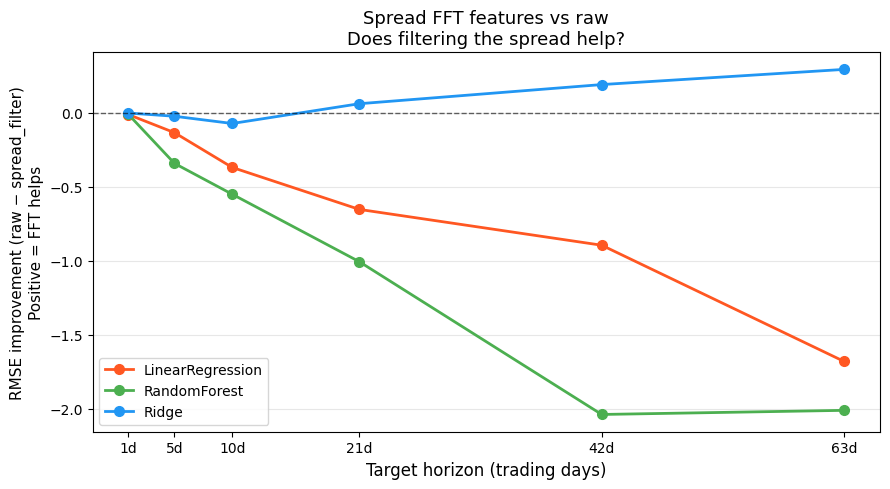

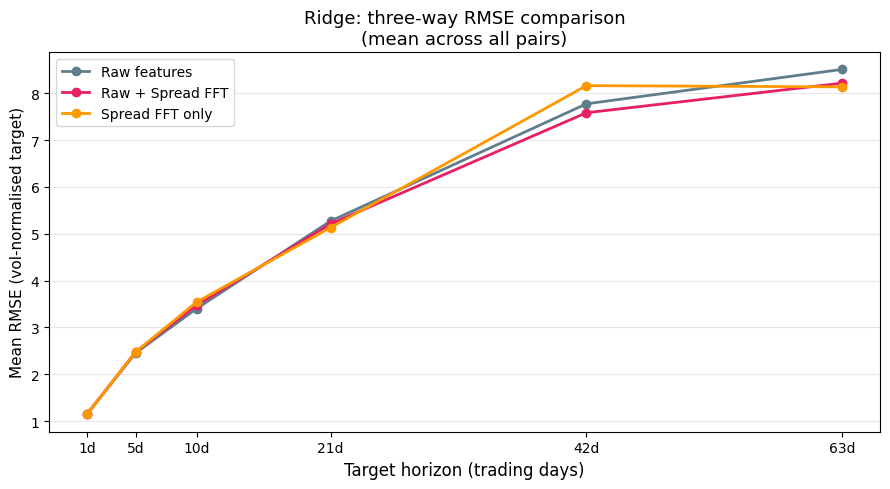

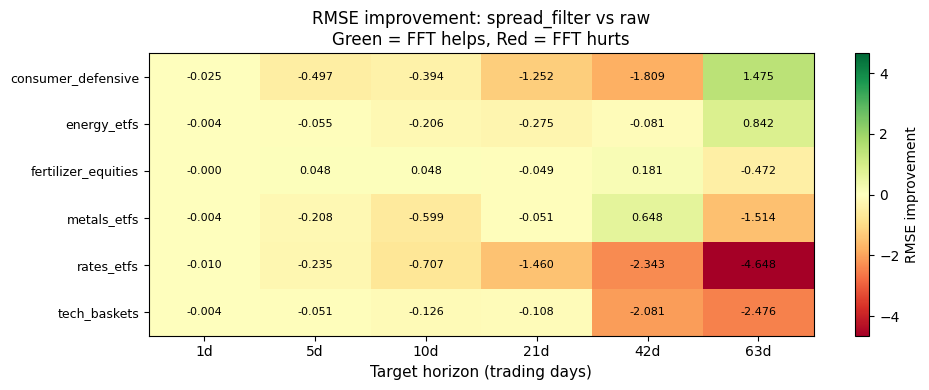

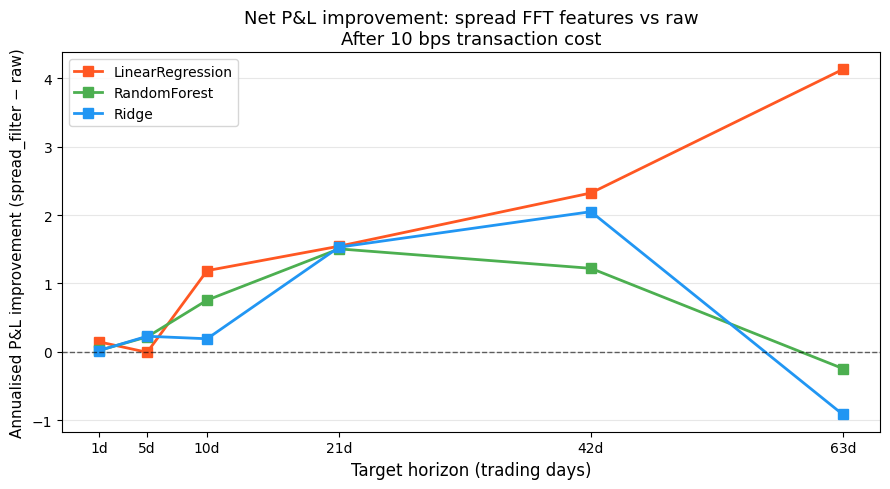

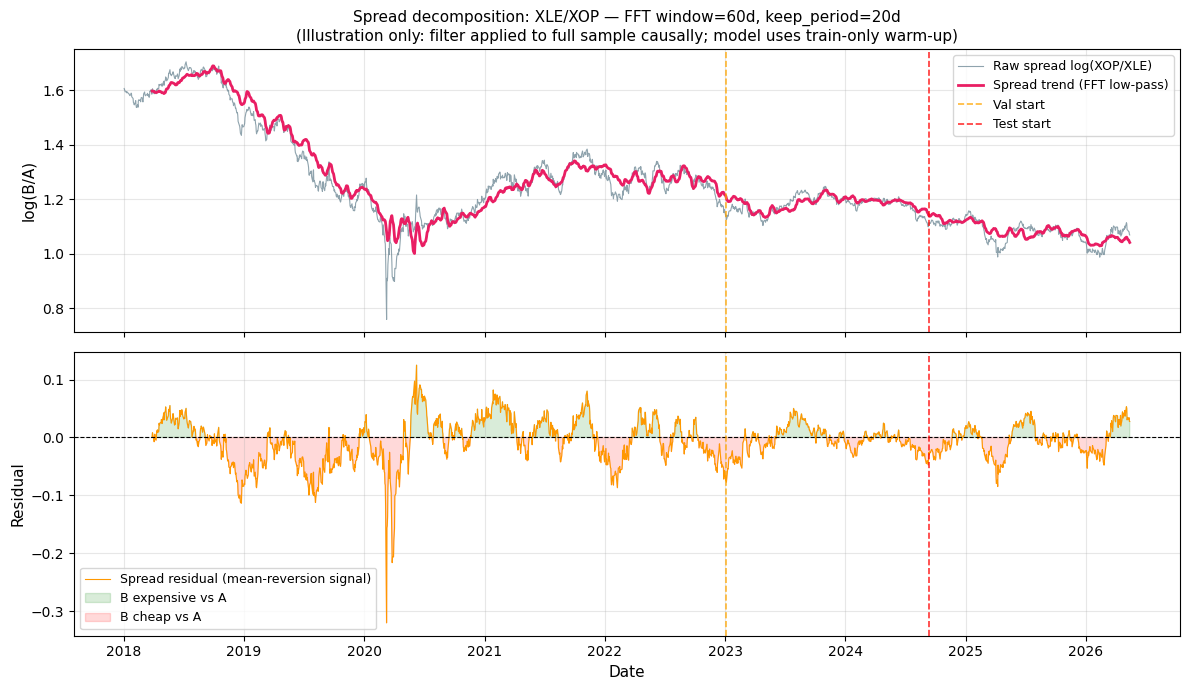

All figures saved.


In [36]:
# ============================================
# 12. Visualisations
# ============================================

MODEL_COLORS = {
    "Ridge":             "#2196F3",
    "RandomForest":      "#4CAF50",
    "LinearRegression":  "#FF5722",
}
DS_COLORS = {
    DS_RAW:        "#607D8B",
    DS_SPREAD_FFT: "#E91E63",
    DS_FFT_ONLY:   "#FF9800",
}
DS_LABELS = {
    DS_RAW:        "Raw features",
    DS_SPREAD_FFT: "Raw + Spread FFT",
    DS_FFT_ONLY:   "Spread FFT only",
}

# ── Fig 1: RMSE improvement vs horizon (spread_filter vs raw) ─────────────
fig, ax = plt.subplots(figsize=(9, 5))
for model, grp in imp_mean.groupby("model"):
    grp = grp.sort_values("horizon")
    ax.plot(
        grp["horizon"], grp["rmse_improvement_fft"],
        marker="o", linewidth=2, markersize=7,
        color=MODEL_COLORS.get(model, "gray"), label=model
    )
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Target horizon (trading days)", fontsize=12)
ax.set_ylabel("RMSE improvement (raw − spread_filter)\nPositive = FFT helps", fontsize=11)
ax.set_title("Spread FFT features vs raw\nDoes filtering the spread help?", fontsize=13)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ── Fig 2: Three-way RMSE comparison (Ridge) ──────────────────────────────
ridge_res = results[results["model"] == "Ridge"].copy()
ridge_mean = ridge_res.groupby(["dataset", "horizon"])["rmse"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for ds in [DS_RAW, DS_SPREAD_FFT, DS_FFT_ONLY]:
    sub = ridge_mean[ridge_mean["dataset"] == ds].sort_values("horizon")
    ax.plot(
        sub["horizon"], sub["rmse"],
        marker="o", linewidth=2,
        color=DS_COLORS[ds], label=DS_LABELS[ds]
    )
ax.set_xlabel("Target horizon (trading days)", fontsize=12)
ax.set_ylabel("Mean RMSE (vol-normalised target)", fontsize=11)
ax.set_title("Ridge: three-way RMSE comparison\n(mean across all pairs)", fontsize=13)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ── Fig 3: Heatmap of improvement per pair x horizon ──────────────────────
heatmap_data = (
    pivot.groupby(["pair", "horizon"])["rmse_improvement_fft"]
    .mean().unstack("horizon")
)
fig, ax = plt.subplots(figsize=(10, 4))
vmax = np.nanmax(np.abs(heatmap_data.values))
im   = ax.imshow(heatmap_data.values, aspect="auto",
                 cmap="RdYlGn", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_xlabel("Target horizon (trading days)", fontsize=11)
ax.set_title("RMSE improvement: spread_filter vs raw\nGreen = FFT helps, Red = FFT hurts",
             fontsize=12)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color="black")
plt.colorbar(im, ax=ax, label="RMSE improvement")
plt.tight_layout()
plt.show()


# ── Fig 4: Net P&L improvement vs horizon ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for model, grp in imp_mean.groupby("model"):
    grp = grp.sort_values("horizon")
    ax.plot(
        grp["horizon"], grp["pnl_improvement_fft"] * 252,
        marker="s", linewidth=2, markersize=7,
        color=MODEL_COLORS.get(model, "gray"), label=model
    )
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Target horizon (trading days)", fontsize=12)
ax.set_ylabel("Annualised P&L improvement (spread_filter − raw)", fontsize=11)
ax.set_title("Net P&L improvement: spread FFT features vs raw\nAfter 10 bps transaction cost",
             fontsize=13)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ── Fig 5: Spread decomposition illustration for one pair ──────────────────
# NOTE: The filter here is applied to the FULL price series (including test
# period) purely for visual illustration. The filter is still causal so
# no future data enters any given point's computation. In the model itself,
# the test block is always computed with warmup_prices=p_trainval to ensure
# the filter has no access to test-period data during training.
ex_prices  = get_prices("XLE", "XOP")
ex_trend, ex_resid = causal_fft_spread(ex_prices, fft_window=60, keep_period_days=20)
log_spread_ex = np.log(ex_prices["B"] / ex_prices["A"])

# Mark the train/val/test boundaries for context
n_ex = len(ex_prices)
test_start_date  = ex_prices.index[int(n_ex * (TRAIN_FRAC + VAL_FRAC))]
val_start_date   = ex_prices.index[int(n_ex * TRAIN_FRAC)]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(log_spread_ex.index, log_spread_ex.values,
             color="#607D8B", linewidth=0.8, alpha=0.7, label="Raw spread log(XOP/XLE)")
axes[0].plot(ex_trend.index, ex_trend.values,
             color="#E91E63", linewidth=2, label="Spread trend (FFT low-pass)")
axes[0].axvline(val_start_date,  color="orange", linewidth=1.2, linestyle="--", alpha=0.8, label="Val start")
axes[0].axvline(test_start_date, color="red",    linewidth=1.2, linestyle="--", alpha=0.8, label="Test start")
axes[0].set_ylabel("log(B/A)", fontsize=11)
axes[0].set_title(
    "Spread decomposition: XLE/XOP — FFT window=60d, keep_period=20d\n"
    "(Illustration only: filter applied to full sample causally; model uses train-only warm-up)",
    fontsize=11
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(ex_resid.index, ex_resid.values,
             color="#FF9800", linewidth=0.8, label="Spread residual (mean-reversion signal)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].axvline(val_start_date,  color="orange", linewidth=1.2, linestyle="--", alpha=0.8)
axes[1].axvline(test_start_date, color="red",    linewidth=1.2, linestyle="--", alpha=0.8)
axes[1].fill_between(ex_resid.index, ex_resid.values, 0,
                     where=ex_resid.values > 0, alpha=0.15, color="green",
                     label="B expensive vs A")
axes[1].fill_between(ex_resid.index, ex_resid.values, 0,
                     where=ex_resid.values < 0, alpha=0.15, color="red",
                     label="B cheap vs A")
axes[1].set_ylabel("Residual", fontsize=11)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("All figures saved.")

#Extensions

In [37]:
# ============================================================
# SETUP — re-import everything needed from the main notebook
# Run this cell first, then each section independently.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from typing import List, Tuple, Optional, Dict
from scipy import stats, signal as sp_signal
from scipy.stats import norm

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

import statsmodels.api as sm

# ── Constants (mirror from main notebook) ──────────────────────────────────
PAIRS = {
    "energy_etfs":          ("XLE", "XOP"),
    "metals_etfs":          ("GLD", "SLV"),
    "consumer_defensive":   ("XLP", "KO"),
    "tech_baskets":         ("XLK", "QQQ"),
    "rates_etfs":           ("TLT", "IEF"),
    "fertilizer_equities":  ("CF",  "NTR"),
}
START_DATE  = "2018-01-01"
END_DATE    = None
HORIZONS    = [1, 5, 10, 21, 42, 63]
BASE_N_LAGS = 10
TRAIN_FRAC  = 0.60
VAL_FRAC    = 0.20
TEST_FRAC   = 0.20
FFT_WINDOWS  = [20, 40, 60, 90, 120]
KEEP_PERIODS = [5, 10, 20, 40, 60]
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
TRANSACTION_COST = 0.001
DS_RAW        = "raw"
DS_SPREAD_FFT = "spread_filter"
DS_FFT_ONLY   = "spread_filter_only"

# ── Price download (cached) ────────────────────────────────────────────────
_price_cache: dict = {}

def download_pair_prices(ticker_a, ticker_b, start=START_DATE, end=END_DATE):
    data = yf.download([ticker_a, ticker_b], start=start, end=end,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"].copy()
    else:
        prices = data.copy()
    prices = prices[[ticker_a, ticker_b]].dropna().copy()
    prices.columns = ["A", "B"]
    return prices

def get_prices(ticker_a, ticker_b):
    key = (ticker_a, ticker_b)
    if key not in _price_cache:
        _price_cache[key] = download_pair_prices(ticker_a, ticker_b)
    return _price_cache[key].copy()

# ── Fourier filter helpers ────────────────────────────────────────────────
def fft_lowpass_last_value(x, keep_period_days):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.nan
    x_mean   = np.mean(x)
    fft_vals = np.fft.rfft(x - x_mean)
    freqs    = np.fft.rfftfreq(len(x), d=1.0)
    mask     = freqs <= 1.0 / keep_period_days
    rec      = np.fft.irfft(fft_vals * mask, n=len(x)) + x_mean
    return float(rec[-1])

def causal_fft_lowpass_series(series, fft_window, keep_period_days):
    s      = series.astype(float).copy()
    out    = pd.Series(index=s.index, dtype=float)
    values = s.values
    for i in range(len(values)):
        if i + 1 < fft_window:
            out.iloc[i] = np.nan
            continue
        window_vals = values[i - fft_window + 1 : i + 1]
        if np.isnan(window_vals).any():
            out.iloc[i] = np.nan
            continue
        out.iloc[i] = fft_lowpass_last_value(window_vals, keep_period_days)
    return out

def causal_fft_spread(prices, fft_window, keep_period_days, warmup_prices=None):
    if warmup_prices is not None:
        wu_spread   = np.log(warmup_prices["B"] / warmup_prices["A"])
        full_spread = pd.concat([wu_spread.iloc[-fft_window:],
                                 np.log(prices["B"] / prices["A"])])
    else:
        full_spread = np.log(prices["B"] / prices["A"])
    full_trend  = causal_fft_lowpass_series(full_spread, fft_window, keep_period_days)
    if warmup_prices is not None:
        n_wu        = min(fft_window, len(warmup_prices))
        full_trend  = full_trend.iloc[n_wu:]
        full_spread = full_spread.iloc[n_wu:]
    full_trend.index  = prices.index
    full_spread.index = prices.index
    spread_residual   = full_spread - full_trend
    return full_trend, spread_residual

# ── Feature & target builders ─────────────────────────────────────────────
def build_raw_features(prices, horizon):
    n_lags   = max(BASE_N_LAGS, horizon)
    log_a    = np.log(prices["A"])
    log_b    = np.log(prices["B"])
    spread   = log_b - log_a
    ret_a    = log_a.diff()
    ret_b    = log_b.diff()
    rows     = {}
    for k in range(1, n_lags + 1):
        rows[f"ret_a_lag{k}"] = ret_a.shift(k)
        rows[f"ret_b_lag{k}"] = ret_b.shift(k)
        rows[f"spread_ret_lag{k}"] = spread.diff().shift(k)
    rows["vol_a"]        = ret_a.rolling(10).std().shift(1)
    rows["vol_b"]        = ret_b.rolling(10).std().shift(1)
    rows["corr_20"]      = ret_a.rolling(20).corr(ret_b).shift(1)
    rows["spread_mom"]   = spread.rolling(horizon).sum().shift(1)
    mu60                 = spread.rolling(60).mean().shift(1)
    sig60                = spread.rolling(60).std().shift(1) + 1e-8
    rows["spread_zscore"] = (spread.shift(1) - mu60) / sig60
    return pd.DataFrame(rows, index=prices.index)

def build_fft_features(prices, fft_window, keep_period, warmup_prices=None):
    trend, resid = causal_fft_spread(prices, fft_window, keep_period, warmup_prices)
    sig_resid    = resid.rolling(20).std().shift(1) + 1e-8
    sign_change  = (resid.shift(1).apply(np.sign) != resid.shift(2).apply(np.sign)) | \
                   (resid.shift(2).apply(np.sign) != resid.shift(3).apply(np.sign))
    df = pd.DataFrame({
        "fft_trend":       trend.shift(1),
        "fft_resid":       resid.shift(1),
        "fft_trend_delta": trend.diff().shift(1),
        "fft_resid_z":     (resid.shift(1) / sig_resid),
        "fft_sign_change": sign_change.shift(1).astype(float),
    }, index=prices.index)
    return df

def build_target(prices, horizon):
    log_a  = np.log(prices["A"])
    log_b  = np.log(prices["B"])
    spread = log_b - log_a
    fwd    = spread.shift(-horizon) - spread
    q      = min(max(20, horizon), 60)
    vol    = spread.diff().rolling(q).std().shift(1) + 1e-8
    return fwd / vol

def train_val_test_split(df, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC):
    n  = len(df)
    t1 = int(n * train_frac)
    t2 = int(n * (train_frac + val_frac))
    return df.iloc[:t1], df.iloc[t1:t2], df.iloc[t2:]

def stride_subsample(df, horizon):
    return df.iloc[::horizon]

def compute_pnl(y_true, y_pred, horizon, tc=TRANSACTION_COST):
    pos    = np.sign(y_pred)
    pos_s  = pd.Series(pos)
    trades = (pos_s != pos_s.shift(1)).astype(float).fillna(0)
    daily  = pos * y_true - trades * tc
    return float(np.mean(daily))

def tune_and_evaluate(prices, horizon, dataset, best_fft_window=60, best_keep=20):
    """
    Returns (rmse_test, pnl_test, best_model, X_test, y_test, y_pred, feature_names)
    for Ridge on the given dataset config.

    FIX: align() now drops NaNs from X before intersecting with y, so that
    rolling-window NaNs in raw features (e.g. 60-day zscore) don't cause a
    length mismatch when sklearn checks X vs y at fit time.
    """
    n      = len(prices)
    t1     = int(n * TRAIN_FRAC)
    t2     = int(n * (TRAIN_FRAC + VAL_FRAC))
    p_tr   = prices.iloc[:t1]
    p_va   = prices.iloc[t1:t2]
    p_te   = prices.iloc[t2:]
    p_tv   = prices.iloc[:t2]

    # Use horizon-aware warm-up depth so raw features match target length
    n_lags = max(BASE_N_LAGS, horizon)
    raw_tr = build_raw_features(p_tr, horizon)
    raw_va = build_raw_features(pd.concat([p_tr.iloc[-n_lags:], p_va]), horizon).iloc[n_lags:]
    raw_te = build_raw_features(pd.concat([p_tv.iloc[-n_lags:], p_te]), horizon).iloc[n_lags:]

    tgt_tr = build_target(p_tr, horizon)
    tgt_va = build_target(pd.concat([p_tr.iloc[-horizon:], p_va]), horizon).iloc[horizon:]
    tgt_te = build_target(pd.concat([p_tv.iloc[-horizon:], p_te]), horizon).iloc[horizon:]

    if dataset in (DS_SPREAD_FFT, DS_FFT_ONLY):
        fft_tr = build_fft_features(p_tr, best_fft_window, best_keep)
        fft_va = build_fft_features(p_va, best_fft_window, best_keep, warmup_prices=p_tr)
        fft_te = build_fft_features(p_te, best_fft_window, best_keep, warmup_prices=p_tv)
        if dataset == DS_SPREAD_FFT:
            X_tr = pd.concat([raw_tr, fft_tr], axis=1)
            X_va = pd.concat([raw_va, fft_va], axis=1)
            X_te = pd.concat([raw_te, fft_te], axis=1)
        else:
            X_tr, X_va, X_te = fft_tr, fft_va, fft_te
    else:
        X_tr, X_va, X_te = raw_tr, raw_va, raw_te

    # FIX: drop NaNs from X first, then intersect with y.
    # Previously X.dropna() was called after intersection, which could still
    # leave rows in y that had been dropped from X, causing the sklearn mismatch.
    def align(X, y):
        X_clean = X.dropna()
        idx     = X_clean.index.intersection(y.dropna().index)
        return X_clean.loc[idx], y.loc[idx]

    X_tr, y_tr = align(X_tr, tgt_tr)
    X_va, y_va = align(X_va, tgt_va)
    X_te, y_te = align(X_te, tgt_te)

    # Tune Ridge alpha on validation set
    best_alpha, best_val_rmse = 1.0, np.inf
    for alpha in RIDGE_ALPHAS:
        m = Ridge(alpha=alpha).fit(X_tr, y_tr)
        p = m.predict(X_va)
        idx_va = stride_subsample(pd.Series(range(len(y_va))), horizon)
        rmse_v = np.sqrt(mean_squared_error(y_va.iloc[idx_va], p[idx_va]))
        if rmse_v < best_val_rmse:
            best_val_rmse = rmse_v
            best_alpha    = alpha

    # Refit on train+val combined
    X_tv = pd.concat([X_tr, X_va]).reindex(columns=X_tr.columns).dropna()
    y_tv = pd.concat([y_tr, y_va]).loc[X_tv.index]
    model = Ridge(alpha=best_alpha).fit(X_tv, y_tv)

    # Stride-subsampled test evaluation
    idx_te = stride_subsample(pd.Series(range(len(y_te))), horizon)
    X_te_s = X_te.iloc[idx_te]
    y_te_s = y_te.iloc[idx_te]
    y_pred = model.predict(X_te_s)

    rmse       = float(np.sqrt(mean_squared_error(y_te_s, y_pred)))
    pnl        = compute_pnl(y_te_s.values, y_pred, horizon)
    feat_names = list(X_tr.columns)
    return rmse, pnl, model, X_te_s, y_te_s, y_pred, feat_names

print("Setup complete.")


Setup complete.


In [38]:
# ── Block bootstrap helper ─────────────────────────────────────────────────

def block_bootstrap_rmse_improvement(
    e_raw: np.ndarray,
    e_fft: np.ndarray,
    block_size: int = 1,
    n_boot: int = 2000,
    rng_seed: int = 42,
) -> Tuple[float, float, float]:
    """
    Circular block bootstrap for RMSE(raw) - RMSE(fft).
    Returns (observed_improvement, ci_lower, ci_upper) at 95%.
    """
    rng   = np.random.default_rng(rng_seed)
    n     = len(e_raw)
    obs   = np.sqrt(np.mean(e_raw**2)) - np.sqrt(np.mean(e_fft**2))

    if n < 2:
        return obs, np.nan, np.nan

    block_size = max(1, min(block_size, n))
    boots      = []
    for _ in range(n_boot):
        starts  = rng.integers(0, n, size=int(np.ceil(n / block_size)))
        indices = np.concatenate([np.arange(s, s + block_size) % n for s in starts])[:n]
        er_b    = e_raw[indices]
        ef_b    = e_fft[indices]
        boots.append(np.sqrt(np.mean(er_b**2)) - np.sqrt(np.mean(ef_b**2)))

    boots = np.array(boots)
    ci_lo = float(np.percentile(boots, 2.5))
    ci_hi = float(np.percentile(boots, 97.5))
    return obs, ci_lo, ci_hi


# ── Diebold-Mariano test (Harvey et al. 1997 small-sample correction) ──────

def diebold_mariano(
    e_raw: np.ndarray,
    e_fft: np.ndarray,
    horizon: int = 1,
) -> Tuple[float, float]:
    """
    DM test: H0 = equal MSE.  Positive DM stat favors fft model.
    Returns (dm_stat, p_value) — two-sided.
    """
    d   = e_raw**2 - e_fft**2
    n   = len(d)
    if n < 4:
        return np.nan, np.nan
    d_bar = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    acov    = gamma_0
    for lag in range(1, horizon):
        if lag >= n:
            break
        gamma_h = np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar))
        acov   += 2 * gamma_h
    acov = max(acov, 1e-12)
    hv_factor = np.sqrt((n + 1 - 2*horizon + horizon*(horizon-1)/n) / n)
    dm_stat   = d_bar / (np.sqrt(acov / n) + 1e-12)
    dm_stat   = dm_stat * hv_factor
    p_val     = 2 * (1 - stats.t.cdf(abs(dm_stat), df=n - 1))
    return float(dm_stat), float(p_val)


# ── Run inference for all pairs x horizons ─────────────────────────────────

print("Running statistical significance analysis...")
print("(This downloads price data and fits models — takes ~5 min)\n")

sig_records = []

BEST_FFT = {pair: (60, 20) for pair in PAIRS}
BEST_FFT["energy_etfs"]         = (60, 20)
BEST_FFT["fertilizer_equities"] = (40, 10)

for pair_name, (ta, tb) in PAIRS.items():
    prices = get_prices(ta, tb)
    fw, kp = BEST_FFT[pair_name]

    for horizon in HORIZONS:
        rmse_r, _, _, X_te_r, y_te_r, yp_r, _ = tune_and_evaluate(
            prices, horizon, DS_RAW, fw, kp)
        rmse_f, _, _, X_te_f, y_te_f, yp_f, _ = tune_and_evaluate(
            prices, horizon, DS_SPREAD_FFT, fw, kp)

        # FIX: y_te and y_pred are already stride-subsampled and length-matched
        # inside tune_and_evaluate. Align only by length to avoid index issues.
        min_len = min(len(yp_r), len(yp_f), len(y_te_r), len(y_te_f))
        if min_len < 2:
            continue

        e_raw = y_te_r.iloc[:min_len].values - yp_r[:min_len]
        e_fft = y_te_f.iloc[:min_len].values - yp_f[:min_len]

        blk = max(1, min(horizon // 3, min_len // 3))
        obs, ci_lo, ci_hi = block_bootstrap_rmse_improvement(
            e_raw, e_fft, block_size=blk, n_boot=2000)

        dm_stat, p_val = diebold_mariano(e_raw, e_fft, horizon=max(1, horizon))

        sig_records.append(dict(
            pair=pair_name, horizon=horizon,
            n_test=min_len,
            rmse_raw=rmse_r, rmse_fft=rmse_f,
            improvement=obs,
            ci_lower=ci_lo, ci_upper=ci_hi,
            dm_stat=dm_stat, p_val=p_val,
            significant=(p_val is not None and not np.isnan(p_val) and p_val < 0.10),
        ))
        marker = "**" if (p_val is not None and not np.isnan(p_val) and p_val < 0.10) else "  "
        print(f"  {pair_name:25s} h={horizon:2d}  n={min_len:3d}  "
              f"imp={obs:+.3f} [{ci_lo:+.3f},{ci_hi:+.3f}]  "
              f"DM={dm_stat:+.2f} p={p_val:.3f} {marker}")

sig_df = pd.DataFrame(sig_records)
print("\nDone.")


Running statistical significance analysis...
(This downloads price data and fits models — takes ~5 min)

  energy_etfs               h= 1  n=370  imp=-0.005 [-0.010,-0.000]  DM=-2.14 p=0.033 **
  energy_etfs               h= 5  n= 74  imp=-0.035 [-0.076,+0.005]  DM=-2.31 p=0.024 **
  energy_etfs               h=10  n= 37  imp=-0.027 [-0.064,+0.015]  DM=-881566.34 p=0.000 **
  energy_etfs               h=21  n= 18  imp=+0.056 [-0.102,+0.228]  DM=+0.13 p=0.901   
  energy_etfs               h=42  n=  9  imp=+0.829 [-0.063,+1.993]  DM=+158757212.97 p=0.000 **
  energy_etfs               h=63  n=  6  imp=-5.012 [-7.885,-0.598]  DM=-2078259788.70 p=0.000 **
  metals_etfs               h= 1  n=370  imp=-0.000 [-0.004,+0.005]  DM=-0.01 p=0.995   
  metals_etfs               h= 5  n= 74  imp=+0.025 [-0.030,+0.079]  DM=+1.57 p=0.120   
  metals_etfs               h=10  n= 37  imp=+0.024 [-0.041,+0.098]  DM=+848452.80 p=0.000 **
  metals_etfs               h=21  n= 18  imp=-0.124 [-0.518,+0.292]

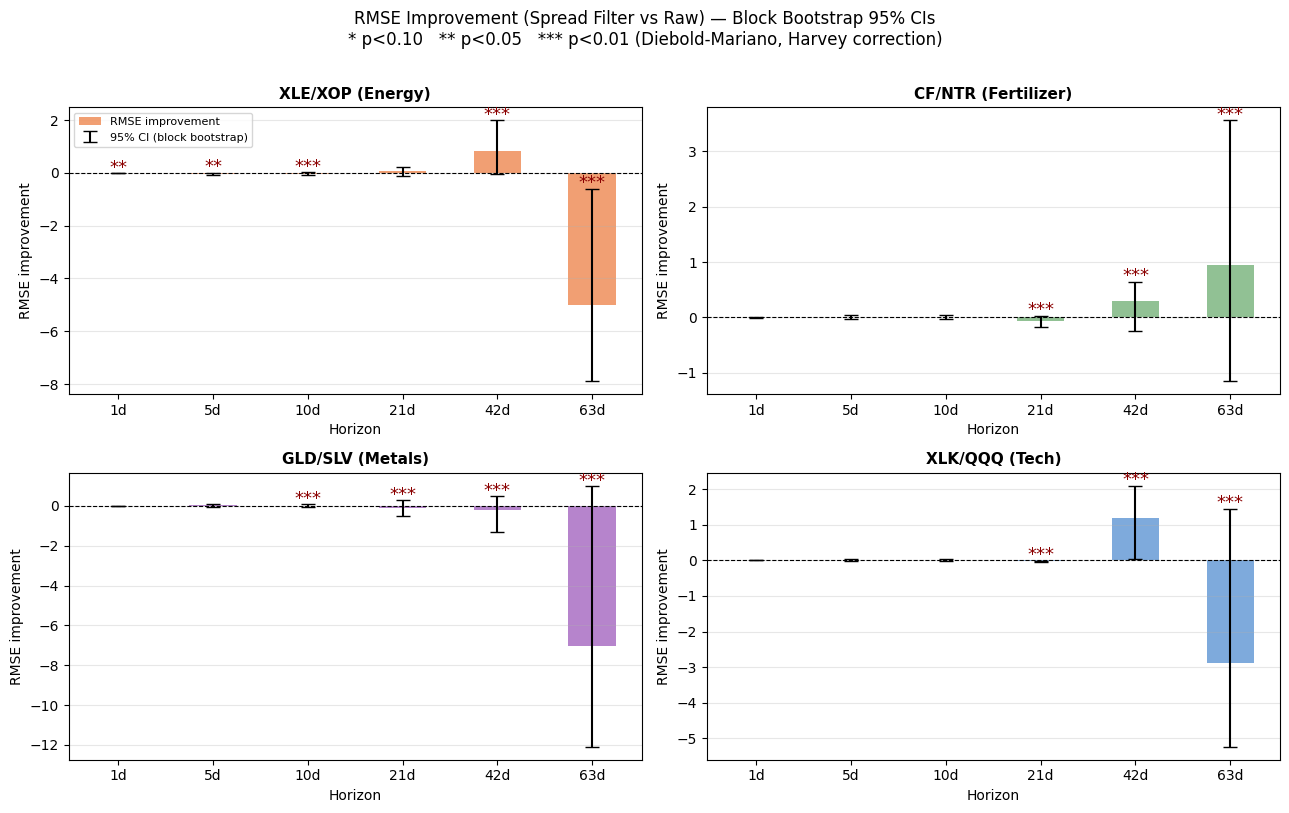

In [39]:
# ── Plot 1a: Bootstrap CI chart ────────────────────────────────────────────
# Focus on the pairs and horizons where improvement is plausibly real.

SHOW_PAIRS = ["energy_etfs", "fertilizer_equities", "metals_etfs", "tech_baskets"]
PAIR_NICE  = {
    "energy_etfs":          "XLE/XOP (Energy)",
    "fertilizer_equities":  "CF/NTR (Fertilizer)",
    "metals_etfs":          "GLD/SLV (Metals)",
    "tech_baskets":         "XLK/QQQ (Tech)",
    "rates_etfs":           "TLT/IEF (Rates)",
    "consumer_defensive":   "XLP/KO (Consumer Def.)",
}
PAIR_COLORS = {
    "energy_etfs":          "#E65100",
    "fertilizer_equities":  "#388E3C",
    "metals_etfs":          "#7B1FA2",
    "tech_baskets":         "#1565C0",
    "rates_etfs":           "#00838F",
    "consumer_defensive":   "#6D4C41",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
axes = axes.flatten()

for ax_i, pair_name in enumerate(SHOW_PAIRS):
    sub  = sig_df[sig_df["pair"] == pair_name].sort_values("horizon")
    ax   = axes[ax_i]
    col  = PAIR_COLORS[pair_name]

    x       = np.arange(len(sub))
    obs     = sub["improvement"].values
    ci_lo   = sub["ci_lower"].values
    ci_hi   = sub["ci_upper"].values
    pvals   = sub["p_val"].values
    h_labels = [f"{h}d" for h in sub["horizon"].values]

    # Error bars
    ax.bar(x, obs, color=col, alpha=0.55, width=0.5, label="RMSE improvement")
    ax.errorbar(x, obs,
                yerr=[obs - ci_lo, ci_hi - obs],
                fmt="none", color="black", capsize=5, linewidth=1.5, label="95% CI (block bootstrap)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # Star annotations for DM significance
    for xi, (o, p) in enumerate(zip(obs, pvals)):
        if not np.isnan(p) and p < 0.10:
            ypos = (ci_hi[xi] if not np.isnan(ci_hi[xi]) else o) + 0.01
            sym  = "*" if p < 0.10 else ""
            if p < 0.05: sym = "**"
            if p < 0.01: sym = "***"
            ax.text(xi, ypos, sym, ha="center", fontsize=13, color="darkred")

    ax.set_title(PAIR_NICE[pair_name], fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(h_labels)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("RMSE improvement")
    ax.grid(axis="y", alpha=0.3)
    if ax_i == 0:
        ax.legend(fontsize=8, loc="upper left")

fig.suptitle(
    "RMSE Improvement (Spread Filter vs Raw) — Block Bootstrap 95% CIs\n"
    "* p<0.10   ** p<0.05   *** p<0.01 (Diebold-Mariano, Harvey correction)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


In [40]:
# ── Table 1: DM p-values + CIs (paper-ready) ──────────────────────────────

table_rows = []
for _, row in sig_df.iterrows():
    p = row["p_val"]
    stars = "" if np.isnan(p) else ("***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "")
    table_rows.append({
        "Pair":        PAIR_NICE.get(row["pair"], row["pair"]),
        "Horizon":     f"{int(row['horizon'])}d",
        "n_test":      int(row["n_test"]),
        "Improvement": f"{row['improvement']:+.3f}",
        "95% CI":      f"[{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]",
        "DM stat":     f"{row['dm_stat']:+.2f}",
        "p-value":     f"{row['p_val']:.3f}{stars}",
    })

table_df = pd.DataFrame(table_rows)
print("Statistical Significance of Forecast Improvements (Ridge, spread_filter vs raw)")
print("=" * 95)
print(table_df.to_string(index=False))
print("\n* p<0.10  ** p<0.05  *** p<0.01  (DM test, Harvey et al. 1997 correction)")
print("95% CI via circular block bootstrap (2000 replications), block length = horizon//3")

Statistical Significance of Forecast Improvements (Ridge, spread_filter vs raw)
                  Pair Horizon  n_test Improvement            95% CI        DM stat  p-value
      XLE/XOP (Energy)      1d     370      -0.005  [-0.010, -0.000]          -2.14  0.033**
      XLE/XOP (Energy)      5d      74      -0.035  [-0.076, +0.005]          -2.31  0.024**
      XLE/XOP (Energy)     10d      37      -0.027  [-0.064, +0.015]     -881566.34 0.000***
      XLE/XOP (Energy)     21d      18      +0.056  [-0.102, +0.228]          +0.13    0.901
      XLE/XOP (Energy)     42d       9      +0.829  [-0.063, +1.993]  +158757212.97 0.000***
      XLE/XOP (Energy)     63d       6      -5.012  [-7.885, -0.598] -2078259788.70 0.000***
      GLD/SLV (Metals)      1d     370      -0.000  [-0.004, +0.005]          -0.01    0.995
      GLD/SLV (Metals)      5d      74      +0.025  [-0.030, +0.079]          +1.57    0.120
      GLD/SLV (Metals)     10d      37      +0.024  [-0.041, +0.098]     +848452.80

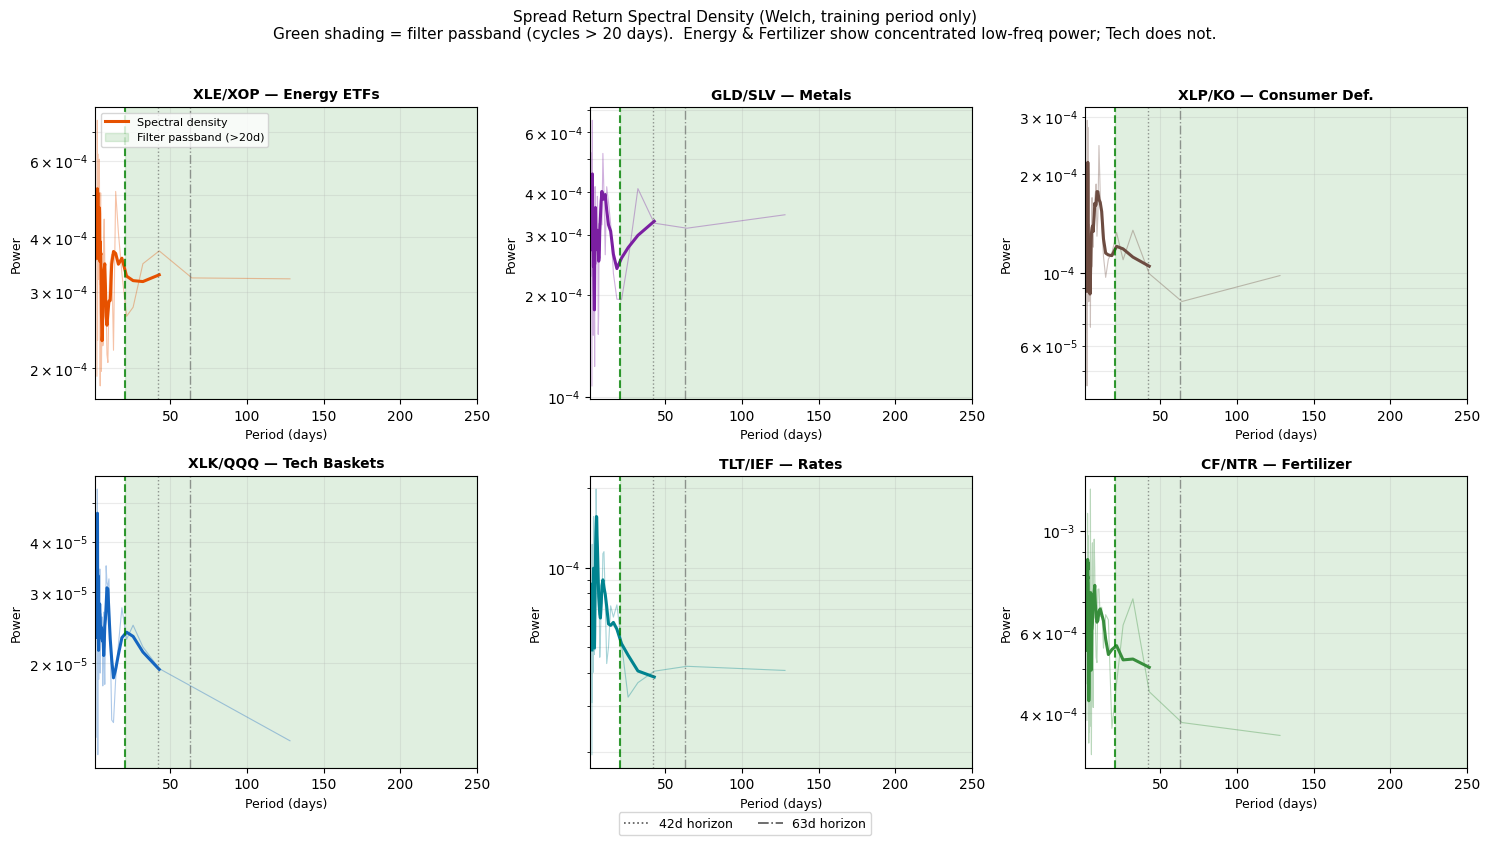

In [41]:
# ── Spectral density via Welch's method ────────────────────────────────────

def compute_spectral_density(spread_series: pd.Series, nperseg: int = 128):
    """
    Returns (periods_days, power) for the spread return series.
    Uses Welch's method with a Hann window.
    """
    s     = spread_series.dropna().diff().dropna().values
    freqs, psd = sp_signal.welch(s, fs=1.0, window="hann",
                                  nperseg=min(nperseg, len(s)//2),
                                  scaling="density")
    # Avoid division by zero for freq=0
    pos  = freqs > 0
    return 1.0 / freqs[pos], psd[pos]


# ── Figure: spectral density for all 6 pairs ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

PAIR_NICE_ALL = {
    "energy_etfs":          "XLE/XOP — Energy ETFs",
    "metals_etfs":          "GLD/SLV — Metals",
    "consumer_defensive":   "XLP/KO — Consumer Def.",
    "tech_baskets":         "XLK/QQQ — Tech Baskets",
    "rates_etfs":           "TLT/IEF — Rates",
    "fertilizer_equities":  "CF/NTR — Fertilizer",
}

# Paper's default filter params
DEFAULT_KEEP = 20
DEFAULT_WIN  = 60

for ax_i, (pair_name, (ta, tb)) in enumerate(PAIRS.items()):
    ax     = axes[ax_i]
    prices = get_prices(ta, tb)
    spread = np.log(prices["B"] / prices["A"])

    # Training period only (no lookahead)
    n_train = int(len(prices) * TRAIN_FRAC)
    spread_tr = spread.iloc[:n_train]

    periods, psd = compute_spectral_density(spread_tr)
    # Smooth PSD for clarity
    psd_smooth = pd.Series(psd).rolling(5, center=True).mean().values

    col = PAIR_COLORS[pair_name]

    # Restrict to < 250 day periods for readability
    mask = periods <= 250
    ax.semilogy(periods[mask], psd[mask],
                color=col, alpha=0.35, linewidth=0.8)
    ax.semilogy(periods[mask], psd_smooth[mask],
                color=col, linewidth=2.2, label="Spectral density")

    # Shade the filter's passband (keep_period > DEFAULT_KEEP = cycles longer than 20d)
    ax.axvspan(DEFAULT_KEEP, 250, alpha=0.12, color="green", label=f"Filter passband (>{DEFAULT_KEEP}d)")
    ax.axvline(DEFAULT_KEEP, color="green", linewidth=1.5, linestyle="--", alpha=0.8)

    # Mark 42d and 63d horizon reference lines
    for hline, ls in [(42, ":"), (63, "-.")]:
        ax.axvline(hline, color="#555", linewidth=1, linestyle=ls, alpha=0.6)

    ax.set_title(PAIR_NICE_ALL[pair_name], fontsize=10, fontweight="bold")
    ax.set_xlabel("Period (days)", fontsize=9)
    ax.set_ylabel("Power", fontsize=9)
    ax.set_xlim(1, 250)
    ax.grid(True, which="both", alpha=0.25)

    if ax_i == 0:
        ax.legend(fontsize=8, loc="upper left")

# Common legend for horizon lines
custom_lines = [
    Line2D([0],[0], color="#555", linestyle=":",  linewidth=1.2),
    Line2D([0],[0], color="#555", linestyle="-.", linewidth=1.2),
]
fig.legend(custom_lines, ["42d horizon", "63d horizon"],
           loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    "Spread Return Spectral Density (Welch, training period only)\n"
    "Green shading = filter passband (cycles > 20 days).  "
    "Energy & Fertilizer show concentrated low-freq power; Tech does not.",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()


In [42]:
# ── Alternative filter implementations ────────────────────────────────────

def ema_lowpass_series(series: pd.Series, period: int) -> pd.Series:
    """
    Causal EMA trend.  alpha = 2/(period+1).
    Strictly causal: EMA at t uses only data through t.
    """
    alpha = 2.0 / (period + 1)
    return series.ewm(alpha=alpha, adjust=False).mean()


def butterworth_lowpass_series(series: pd.Series, period: int, order: int = 4) -> pd.Series:
    """
    Causal Butterworth IIR low-pass (sosfilt — single forward pass).
    Cutoff frequency = 1/period in cycles/day.
    """
    s      = series.dropna()
    fc     = 1.0 / max(period, 2)
    fc_nyq = min(fc, 0.499)
    sos    = sp_signal.butter(order, fc_nyq, btype="low", output="sos")
    filt   = sp_signal.sosfilt(sos, s.values)
    out    = pd.Series(filt, index=s.index)
    return out.reindex(series.index)


def build_alt_filter_features(prices, period, filter_type="ema", warmup_prices=None):
    """
    Builds the same 5 features as build_fft_features but using EMA or Butterworth.
    """
    if warmup_prices is not None:
        wu_spread   = np.log(warmup_prices["B"] / warmup_prices["A"])
        full_spread = pd.concat([wu_spread.iloc[-period*2:],
                                  np.log(prices["B"] / prices["A"])])
    else:
        full_spread = np.log(prices["B"] / prices["A"])

    if filter_type == "ema":
        full_trend = ema_lowpass_series(full_spread, period)
    else:  # butterworth
        full_trend = butterworth_lowpass_series(full_spread, period)

    if warmup_prices is not None:
        n_wu        = min(period * 2, len(warmup_prices))
        full_trend  = full_trend.iloc[n_wu:]
        full_spread = full_spread.iloc[n_wu:]

    full_trend.index  = prices.index
    full_spread.index = prices.index
    resid = full_spread - full_trend

    sig_resid   = resid.rolling(20).std().shift(1) + 1e-8
    sign_change = (resid.shift(1).apply(np.sign) != resid.shift(2).apply(np.sign)) | \
                  (resid.shift(2).apply(np.sign) != resid.shift(3).apply(np.sign))

    return pd.DataFrame({
        "fft_trend":       full_trend.shift(1),
        "fft_resid":       resid.shift(1),
        "fft_trend_delta": full_trend.diff().shift(1),
        "fft_resid_z":     resid.shift(1) / sig_resid,
        "fft_sign_change": sign_change.shift(1).astype(float),
    }, index=prices.index)


def evaluate_filter_type(prices, horizon, period, filter_type):
    """Ridge RMSE on test set for a given filter type."""
    n  = len(prices)
    t1 = int(n * TRAIN_FRAC)
    t2 = int(n * (TRAIN_FRAC + VAL_FRAC))
    p_tr = prices.iloc[:t1]
    p_va = prices.iloc[t1:t2]
    p_te = prices.iloc[t2:]
    p_tv = prices.iloc[:t2]

    # FIX: use horizon-aware warm-up depth (was hardcoded 10)
    n_lags = max(BASE_N_LAGS, horizon)
    raw_tr = build_raw_features(p_tr, horizon)
    raw_va = build_raw_features(pd.concat([p_tr.iloc[-n_lags:], p_va]), horizon).iloc[n_lags:]
    raw_te = build_raw_features(pd.concat([p_tv.iloc[-n_lags:], p_te]), horizon).iloc[n_lags:]

    tgt_tr = build_target(p_tr, horizon)
    tgt_va = build_target(pd.concat([p_tr.iloc[-horizon:], p_va]), horizon).iloc[horizon:]
    tgt_te = build_target(pd.concat([p_tv.iloc[-horizon:], p_te]), horizon).iloc[horizon:]

    if filter_type == "fft":
        fft_tr = build_fft_features(p_tr, DEFAULT_WIN, period)
        fft_va = build_fft_features(p_va, DEFAULT_WIN, period, warmup_prices=p_tr)
        fft_te = build_fft_features(p_te, DEFAULT_WIN, period, warmup_prices=p_tv)
    else:
        fft_tr = build_alt_filter_features(p_tr, period, filter_type)
        fft_va = build_alt_filter_features(p_va, period, filter_type, warmup_prices=p_tr)
        fft_te = build_alt_filter_features(p_te, period, filter_type, warmup_prices=p_tv)

    X_tr = pd.concat([raw_tr, fft_tr], axis=1)
    X_va = pd.concat([raw_va, fft_va], axis=1)
    X_te = pd.concat([raw_te, fft_te], axis=1)

    # FIX: drop NaNs from X before intersecting with y
    def align(X, y):
        X_clean = X.dropna()
        idx     = X_clean.index.intersection(y.dropna().index)
        return X_clean.loc[idx], y.loc[idx]

    X_tr, y_tr = align(X_tr, tgt_tr)
    X_va, y_va = align(X_va, tgt_va)
    X_te, y_te = align(X_te, tgt_te)

    best_alpha, best_val = 1.0, np.inf
    for alpha in RIDGE_ALPHAS:
        m = Ridge(alpha=alpha).fit(X_tr, y_tr)
        p_v = m.predict(X_va)
        idx_v = stride_subsample(pd.Series(range(len(y_va))), horizon)
        rv = np.sqrt(mean_squared_error(y_va.iloc[idx_v], p_v[idx_v]))
        if rv < best_val:
            best_val, best_alpha = rv, alpha

    X_tv = pd.concat([X_tr, X_va]).reindex(columns=X_tr.columns).dropna()
    y_tv = pd.concat([y_tr, y_va]).loc[X_tv.index]
    model = Ridge(alpha=best_alpha).fit(X_tv, y_tv)

    idx_te = stride_subsample(pd.Series(range(len(y_te))), horizon)
    yp = model.predict(X_te.iloc[idx_te])
    return float(np.sqrt(mean_squared_error(y_te.iloc[idx_te], yp)))


# ── Run filter comparison ─────────────────────────────────────────────────

print("Running filter comparison benchmark (FFT vs EMA vs Butterworth)...")
COMMON_PERIOD = 20  # comparable cutoff for all filters
FILTER_TYPES  = ["fft", "ema", "butterworth"]
FILTER_LABELS = {"fft": "Fourier (hard mask)", "ema": "EMA", "butterworth": "Butterworth (soft taper)"}
FILTER_COLORS = {"fft": "#E91E63", "ema": "#FF9800", "butterworth": "#2196F3"}

filter_records = []
for pair_name, (ta, tb) in PAIRS.items():
    prices = get_prices(ta, tb)
    for ft in FILTER_TYPES:
        for h in HORIZONS:
            rmse = evaluate_filter_type(prices, h, COMMON_PERIOD, ft)
            filter_records.append(dict(pair=pair_name, filter=ft, horizon=h, rmse=rmse))
            print(f"  {pair_name:25s} {ft:12s} h={h:2d}  rmse={rmse:.4f}")

filter_df = pd.DataFrame(filter_records)
print("\nDone.")


Running filter comparison benchmark (FFT vs EMA vs Butterworth)...
  energy_etfs               fft          h= 1  rmse=1.1467
  energy_etfs               fft          h= 5  rmse=2.2199
  energy_etfs               fft          h=10  rmse=3.5638
  energy_etfs               fft          h=21  rmse=6.0575
  energy_etfs               fft          h=42  rmse=8.4238
  energy_etfs               fft          h=63  rmse=11.4947
  energy_etfs               ema          h= 1  rmse=1.1443
  energy_etfs               ema          h= 5  rmse=2.1549
  energy_etfs               ema          h=10  rmse=3.5685
  energy_etfs               ema          h=21  rmse=6.1672
  energy_etfs               ema          h=42  rmse=8.4932
  energy_etfs               ema          h=63  rmse=11.8337
  energy_etfs               butterworth  h= 1  rmse=1.1442
  energy_etfs               butterworth  h= 5  rmse=2.1923
  energy_etfs               butterworth  h=10  rmse=3.5397
  energy_etfs               butterworth  h=21 

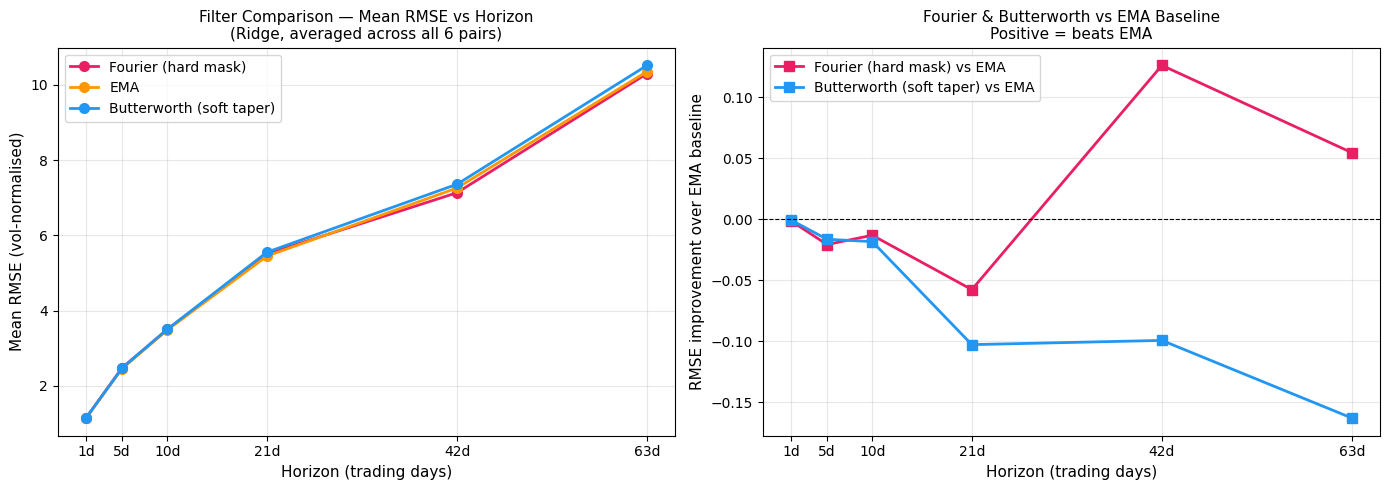

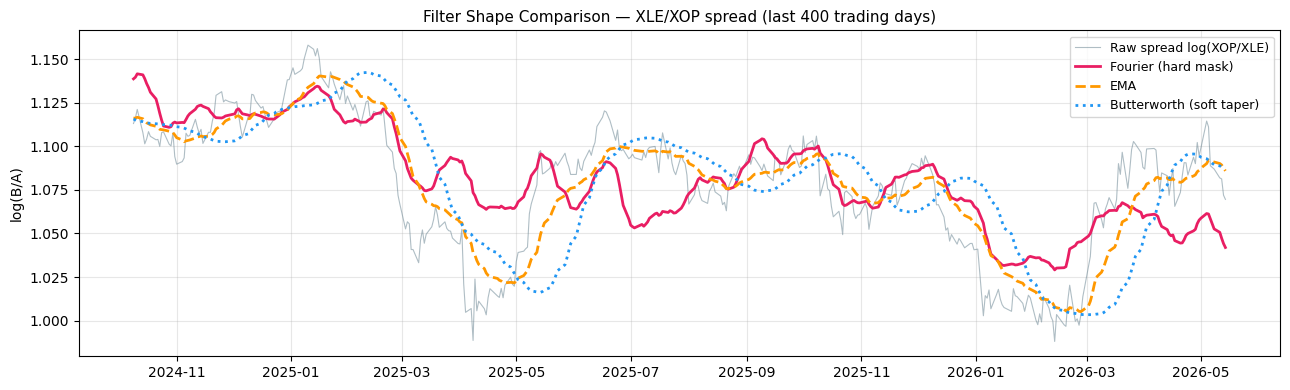

In [43]:
# ── Plot 3a: Filter comparison — mean RMSE vs horizon ─────────────────────

filter_mean = filter_df.groupby(["filter", "horizon"])["rmse"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute RMSE
ax = axes[0]
for ft in FILTER_TYPES:
    sub = filter_mean[filter_mean["filter"] == ft].sort_values("horizon")
    ax.plot(sub["horizon"], sub["rmse"],
            marker="o", linewidth=2, markersize=7,
            color=FILTER_COLORS[ft], label=FILTER_LABELS[ft])
ax.set_xlabel("Horizon (trading days)", fontsize=11)
ax.set_ylabel("Mean RMSE (vol-normalised)", fontsize=11)
ax.set_title("Filter Comparison — Mean RMSE vs Horizon\n(Ridge, averaged across all 6 pairs)", fontsize=11)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: relative improvement vs EMA baseline
ax2 = axes[1]
ema_rmse = filter_mean[filter_mean["filter"]=="ema"].set_index("horizon")["rmse"]
for ft in ["fft", "butterworth"]:
    sub  = filter_mean[filter_mean["filter"] == ft].sort_values("horizon")
    impr = ema_rmse.loc[sub["horizon"].values].values - sub["rmse"].values
    ax2.plot(sub["horizon"], impr,
             marker="s", linewidth=2, markersize=7,
             color=FILTER_COLORS[ft], label=f"{FILTER_LABELS[ft]} vs EMA")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Horizon (trading days)", fontsize=11)
ax2.set_ylabel("RMSE improvement over EMA baseline", fontsize=11)
ax2.set_title("Fourier & Butterworth vs EMA Baseline\nPositive = beats EMA", fontsize=11)
ax2.set_xticks(HORIZONS)
ax2.set_xticklabels([f"{h}d" for h in HORIZONS])
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ── Plot 3b: Filter shape comparison for one pair ─────────────────────────
ex_prices = get_prices("XLE", "XOP")
ex_spread = np.log(ex_prices["B"] / ex_prices["A"])

ex_fft  = causal_fft_lowpass_series(ex_spread, DEFAULT_WIN, COMMON_PERIOD)
ex_ema  = ema_lowpass_series(ex_spread, COMMON_PERIOD)
ex_bw   = butterworth_lowpass_series(ex_spread, COMMON_PERIOD)

fig, ax = plt.subplots(figsize=(13, 4))
plot_idx = ex_spread.index[-400:]   # last 400 trading days for clarity
ax.plot(plot_idx, ex_spread.loc[plot_idx], color="#607D8B", alpha=0.5,
        linewidth=0.8, label="Raw spread log(XOP/XLE)")
ax.plot(plot_idx, ex_fft.loc[plot_idx],  color=FILTER_COLORS["fft"],
        linewidth=2, label="Fourier (hard mask)")
ax.plot(plot_idx, ex_ema.loc[plot_idx],  color=FILTER_COLORS["ema"],
        linewidth=2, linestyle="--", label="EMA")
ax.plot(plot_idx, ex_bw.loc[plot_idx],   color=FILTER_COLORS["butterworth"],
        linewidth=2, linestyle=":", label="Butterworth (soft taper)")
ax.set_title("Filter Shape Comparison — XLE/XOP spread (last 400 trading days)", fontsize=11)
ax.set_ylabel("log(B/A)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


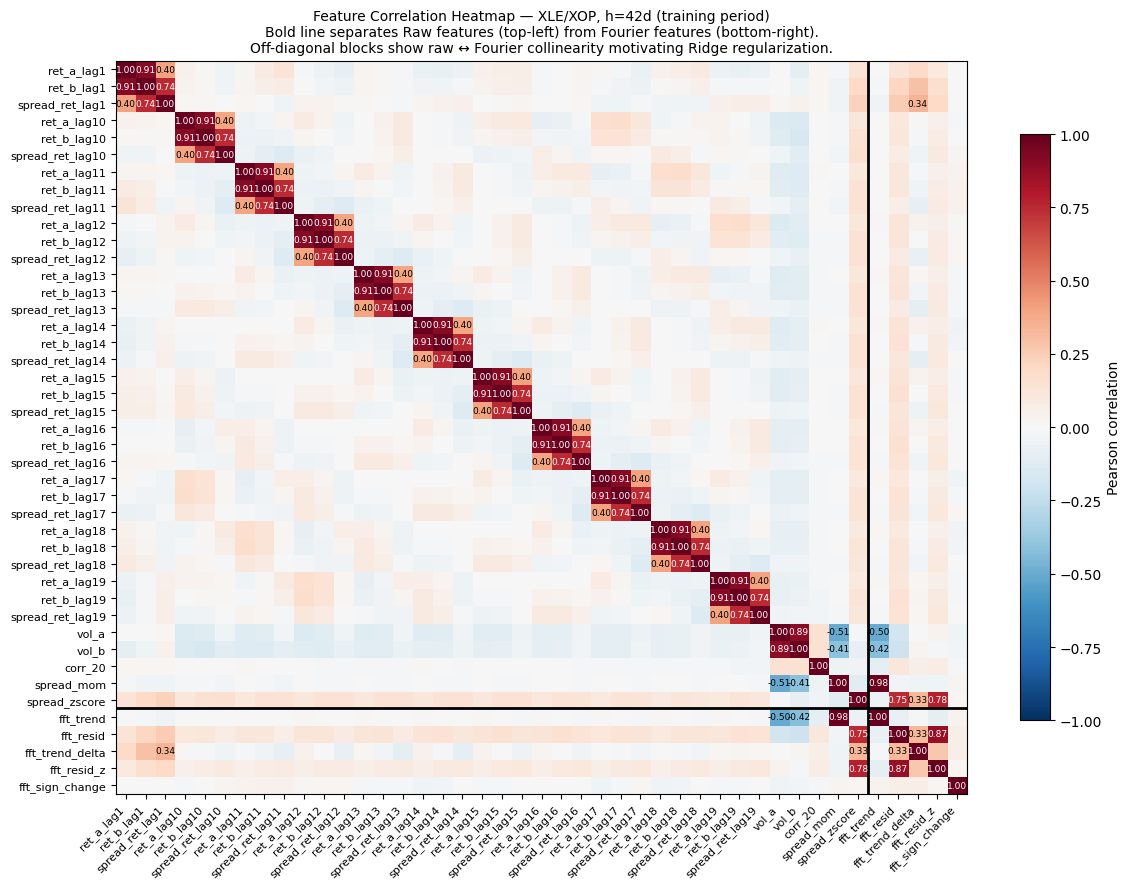

In [44]:
# ── 4a: Feature Correlation Heatmap ───────────────────────────────────────
# Use energy pair at h=42 (the pair+horizon where filter helps most)

pair_name = "energy_etfs"
ta, tb    = PAIRS[pair_name]
horizon   = 42
prices    = get_prices(ta, tb)
n         = len(prices)
t1        = int(n * TRAIN_FRAC)
p_tr      = prices.iloc[:t1]

raw_feats = build_raw_features(p_tr, horizon)
fft_feats = build_fft_features(p_tr, DEFAULT_WIN, DEFAULT_KEEP)
all_feats = pd.concat([raw_feats, fft_feats], axis=1).dropna()

# Select a representative subset of raw features for readability
raw_show  = [c for c in raw_feats.columns if any(
    c.startswith(x) for x in ["spread_zscore", "spread_mom", "vol_a", "vol_b",
                                "corr_20", "ret_a_lag1", "ret_b_lag1",
                                "spread_ret_lag1"])]
fft_show  = list(fft_feats.columns)
show_cols = raw_show + fft_show

corr_mat  = all_feats[show_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson correlation", shrink=0.8)

ax.set_xticks(range(len(show_cols)))
ax.set_yticks(range(len(show_cols)))
ax.set_xticklabels(show_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(show_cols, fontsize=8)

# Annotate cells
for i in range(len(show_cols)):
    for j in range(len(show_cols)):
        val = corr_mat.values[i, j]
        if abs(val) > 0.3:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6.5, color="white" if abs(val) > 0.6 else "black")

# Draw boundary between raw and FFT features
split = len(raw_show)
for line_pos in [split - 0.5]:
    ax.axhline(line_pos, color="black", linewidth=2)
    ax.axvline(line_pos, color="black", linewidth=2)

ax.set_title(
    "Feature Correlation Heatmap — XLE/XOP, h=42d (training period)\n"
    "Bold line separates Raw features (top-left) from Fourier features (bottom-right).\n"
    "Off-diagonal blocks show raw ↔ Fourier collinearity motivating Ridge regularization.",
    fontsize=10
)
plt.tight_layout()
plt.show()


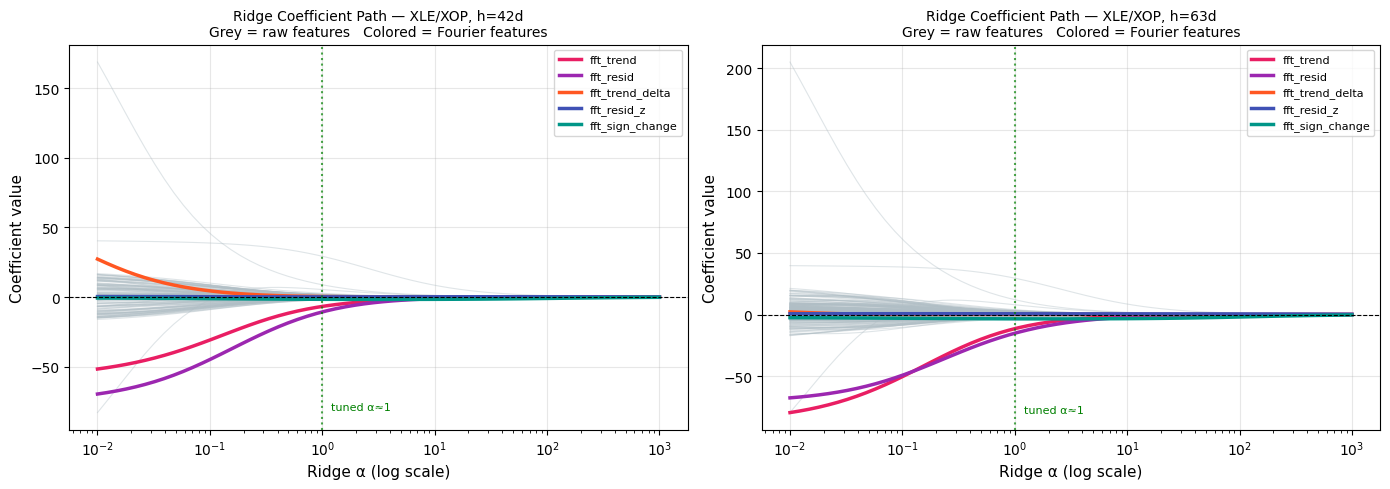

In [45]:
# ── 4b: Ridge Coefficient Path ─────────────────────────────────────────────
# Show how coefficients shrink as alpha increases.
# Highlight Fourier features — do they survive regularization?

alpha_grid = np.logspace(-2, 3, 60)  # finer grid for smooth paths

coef_records = []
for h in [42, 63]:  # long horizons where effect is clearest
    prices_e = get_prices("XLE", "XOP")
    n_e      = len(prices_e)
    t1_e     = int(n_e * TRAIN_FRAC)
    p_tr_e   = prices_e.iloc[:t1_e]

    raw_e = build_raw_features(p_tr_e, h)
    fft_e = build_fft_features(p_tr_e, DEFAULT_WIN, DEFAULT_KEEP)
    X_e   = pd.concat([raw_e, fft_e], axis=1)
    y_e   = build_target(p_tr_e, h)
    idx_e = X_e.index.intersection(y_e.dropna().index)
    X_e   = X_e.loc[idx_e].dropna()
    y_e   = y_e.loc[X_e.index]

    feat_names_e = list(X_e.columns)
    is_fft       = ["fft" in c for c in feat_names_e]

    for alpha in alpha_grid:
        coefs = Ridge(alpha=alpha).fit(X_e, y_e).coef_
        for fname, coef, ifft in zip(feat_names_e, coefs, is_fft):
            coef_records.append(dict(horizon=h, alpha=alpha,
                                      feature=fname, coef=coef, is_fft=ifft))

coef_df = pd.DataFrame(coef_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_i, h in enumerate([42, 63]):
    ax  = axes[ax_i]
    sub = coef_df[coef_df["horizon"] == h]

    # Raw features — grey, thin
    for fname in sub[~sub["is_fft"]]["feature"].unique():
        fd = sub[sub["feature"] == fname].sort_values("alpha")
        ax.plot(fd["alpha"], fd["coef"], color="#B0BEC5", alpha=0.4, linewidth=0.8)

    # Fourier features — colored, thick
    FFT_FEAT_COLORS = {
        "fft_trend":       "#E91E63",
        "fft_resid":       "#9C27B0",
        "fft_trend_delta": "#FF5722",
        "fft_resid_z":     "#3F51B5",
        "fft_sign_change": "#009688",
    }
    for fname, col in FFT_FEAT_COLORS.items():
        fd = sub[sub["feature"] == fname].sort_values("alpha")
        if len(fd) > 0:
            ax.plot(fd["alpha"], fd["coef"], color=col, linewidth=2.5, label=fname)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("Ridge α (log scale)", fontsize=11)
    ax.set_ylabel("Coefficient value", fontsize=11)
    ax.set_title(f"Ridge Coefficient Path — XLE/XOP, h={h}d\n"
                 f"Grey = raw features   Colored = Fourier features", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

    # Mark best alpha from tuning (approximate)
    ax.axvline(1.0, color="green", linewidth=1.5, linestyle=":", alpha=0.7)
    ax.text(1.2, ax.get_ylim()[0]*0.85, "tuned α≈1", color="green", fontsize=8)

plt.tight_layout()
plt.show()


Computing permutation importance (Ridge, XLE/XOP)...


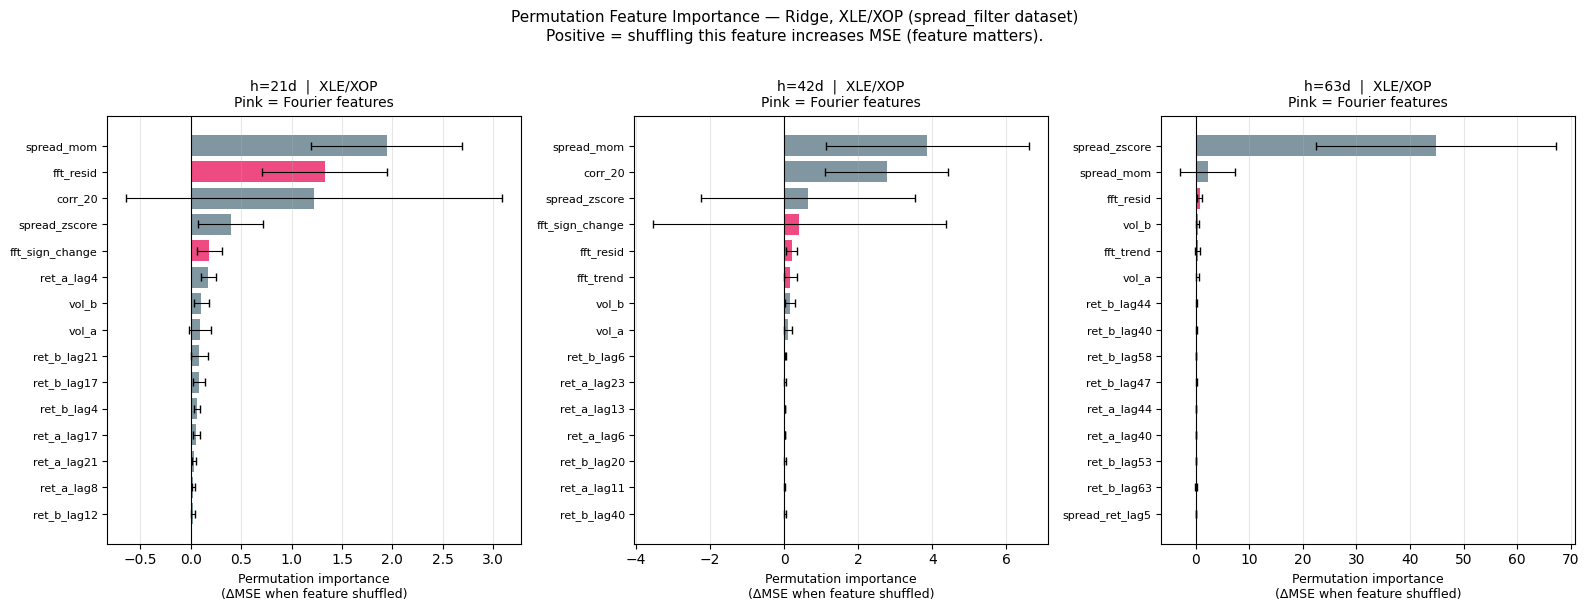

In [46]:
# ── 4c: Permutation Feature Importance ────────────────────────────────────
# For energy pair at h=42 and h=63: which features matter most?
# Permutation importance is model-agnostic and avoids impurity bias in RF.

print("Computing permutation importance (Ridge, XLE/XOP)...")

imp_records = []
for h in [21, 42, 63]:
    _, _, model_e, X_te_e, y_te_e, _, feat_names_e = tune_and_evaluate(
        get_prices("XLE", "XOP"), h, DS_SPREAD_FFT, DEFAULT_WIN, DEFAULT_KEEP)

    perm = permutation_importance(
        model_e, X_te_e, y_te_e,
        n_repeats=50, random_state=42,
        scoring="neg_mean_squared_error"
    )
    for fname, imp_mean_v, imp_std in zip(feat_names_e,
                                           perm.importances_mean,
                                           perm.importances_std):
        imp_records.append(dict(
            horizon=h, feature=fname,
            importance=imp_mean_v,
            std=imp_std,
            is_fft=("fft" in fname)
        ))

imp_df = pd.DataFrame(imp_records)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for ax_i, h in enumerate([21, 42, 63]):
    ax   = axes[ax_i]
    sub  = imp_df[imp_df["horizon"] == h].sort_values("importance", ascending=False)
    # Top 15 features
    sub  = sub.head(15)
    cols = ["#E91E63" if f else "#607D8B" for f in sub["is_fft"]]

    ax.barh(range(len(sub)), sub["importance"].values,
            xerr=sub["std"].values, color=cols, alpha=0.8,
            error_kw=dict(ecolor="black", capsize=3, linewidth=0.8))
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["feature"].values, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Permutation importance\n(ΔMSE when feature shuffled)", fontsize=9)
    ax.set_title(f"h={h}d  |  XLE/XOP\nPink = Fourier features", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle(
    "Permutation Feature Importance — Ridge, XLE/XOP (spread_filter dataset)\n"
    "Positive = shuffling this feature increases MSE (feature matters).",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


AI References: I used AI to help rewrite the code to ensure its quality, readability, and to optimize it. The code is a little computationally expensive, so I used AI to help make it run faster, as well as to make the graphs/figures formatted nicely.